**EC ENG 232E - Summer 25 - Project 1**

Team members:
*   Kaylee Lo (UID: 005-307-797), kayleelo@g.ucla.edu
*   Joanna Tang (UID: 602-503-690), joannat@g.ucla.edu
*   Rachel Zhang (UID: 705-413-148), rzhang319@g.ucla.edu





In [ ]:
install.packages("igraph")
install.packages("ggplot2")
library(igraph)
library(ggplot2)
options(repr.plot.width=6, repr.plot.height=5)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




# A. Generating Random Networks


## 1) Create random networks using Erd¨os-R´enyi (ER) model


### a. Create undirected random networks with n=900

In [ ]:
n <- 900
prob_values <- c(0.002, 0.006, 0.012, 0.045, 0.1)
set.seed(2025)

# generate networks using sample_gnp
networks <- list()
for (i in 1:length(prob_values)) {
  p <- prob_values[i]
  networks[[i]] <- sample_gnp(n, p, directed = FALSE)
}

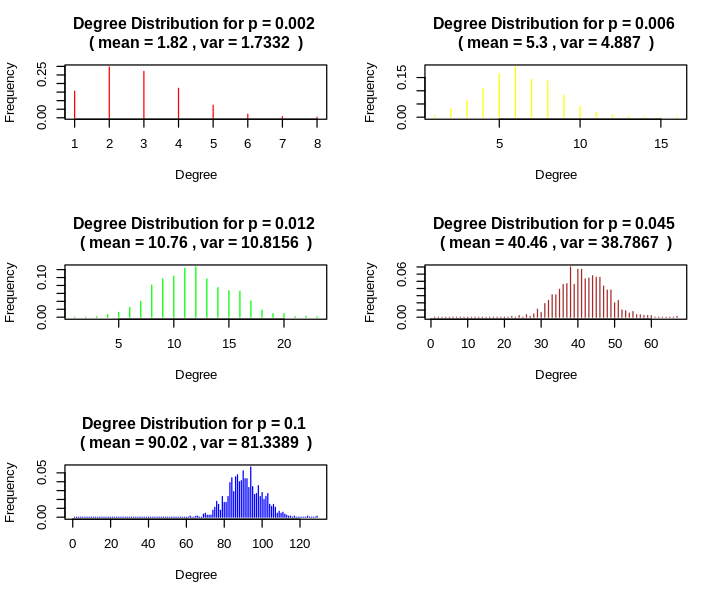

In [ ]:
# plot the degree distribution
par(mfrow = c(3,2))
colors <- c("red", "yellow", "green", "brown", "blue")
for (i in 1:length(prob_values)) {
  g <- degree_distribution(networks[[i]])
  deg <- degree(networks[[i]])
  m <- mean(deg)
  v <- var(deg)

  plot(g, type="h",col = colors[i], xlab="Degree", ylab="Frequency",
  main = paste("Degree Distribution for p =", prob_values[i],
  "\n( mean =", round(m, 2), ", var =", round(v, 4), " )") )
}

What distribution (linear/exponential/gaussian/binomial or something else) is observed? Explain why. Also, report the mean and variance of the degree distributions and compare them to the theoretical values.

**Answer:**
The distribution of a random network based on the ER model follows a binomial distribution. This is binomial because the number of degree (number of nodes) that each node can connect to is fixed at n-1 while each node connecting to another is independent of the other nodes' degrees. Thus, the distribution of the node degrees to the frequency of the observed degree reflects a binomial distribution. It is observed that both the mean and variance values increase as the probability increases.

Given the small probability and the skew in the output, the p=0.002 graph may also reflect a Poisson distribution which can be observed as networks get larger and edge probabilities get smaller.

Calculate the theoretical means and variances and compare with above model values:

| p     | mean = n*p | variance = n* p *(1-p) |  emp mean | emp variance |
|-------|------------|----------------------|------------|----------------------|
| 0.002 | 1.8        | 1.7964               | 1.82  | 1.7332   |
| 0.006 | 5.4        | 5.3676               | 5.3   | 4.887    |
| 0.012 | 10.8       | 10.6704              | 10.76 | 10.8156  |
| 0.045 | 40.5       | 38.6475              | 40.46 | 38.7867  |
| 0.1   | 90         | 81                   | 90.02 | 81.3389  |

**Answer:** As seen in the table above, the empirical or observed mean and variance is very similar to the theoretical mean and variance. For example, looking at the model in which p=0.002, the theoretical mean is 1.8 while the empirical mean is slightly higher at 1.82. This is similar to the variance using p=0.002 which is slightly smaller than the theoretically calculated variance. Thus, the random models we created accurately represent the theoretical models calculated in ER. Comparing the theoretical means and variances to the empirical means and variances of our models do not result in significant differences.

The most notable observation is that as the p value increases when creating the model, both the mean and variance increase. As the mean increases, the variance gets very large, but still follows a binomial distribution and a bell shaped curve as seen in the graphs above.

### b. For each p and n = 900, answer the following questions:

Are all random realizations of the ER network connected? Numerically estimate the probability that a generated network is connected. For one instance of the networks with that p, find the giant connected component (GCC) if not connected. What is the diameter of the GCC?
Hint Useful function(s): isconnected , clusters , diameter

**Answer:** As shown in the graphs below, not all random realizations of the ER network are connected. The probability that a generated network is connected is calculated below.

Probablility threshold:

$$ p_c = \frac{ln (n)} {n} = \frac {ln (900)} {900} = 0.00756 $$

This is consistent with the result below. For p = 0.012, 0.045, and 0.1, p > $p_c$ the generated networks are connected. For p = 0.002 and 0.006, p < $p_c$, the generated networks are NOT connected.

[1] "p =  0.002 is NOT connected"
[1] "GCC Diameter = 29"


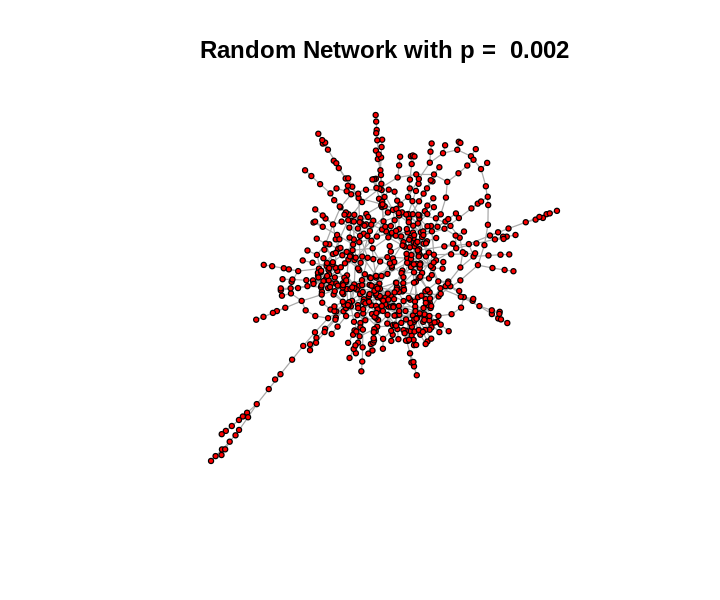

[1] "p =  0.006 is NOT connected"
[1] "GCC Diameter = 9"


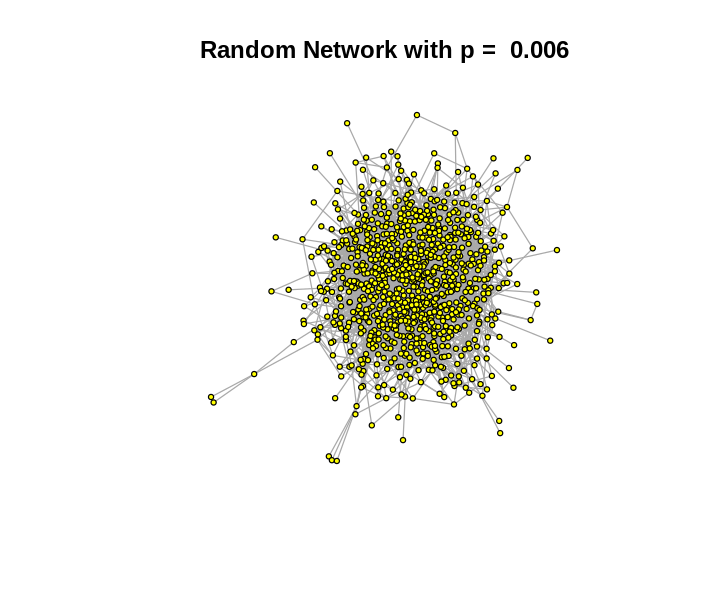

[1] "p =  0.012 is connected"
[1] "GCC Diameter = 5"


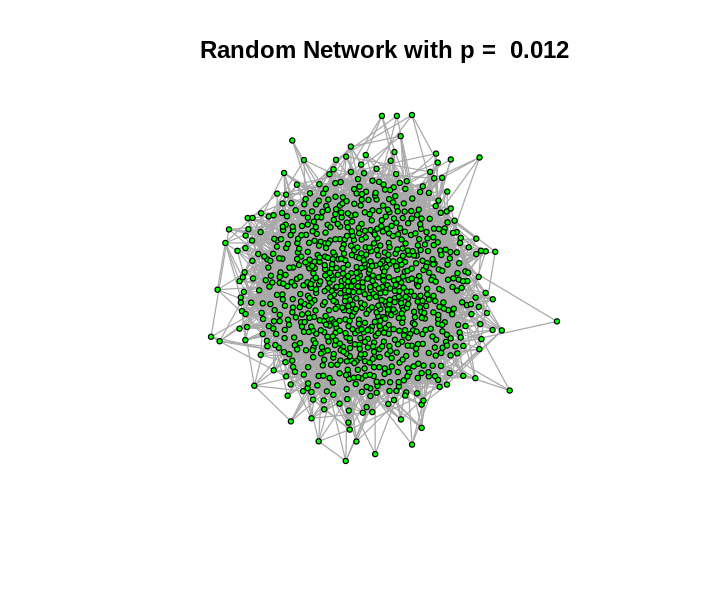

[1] "p =  0.045 is connected"
[1] "GCC Diameter = 3"


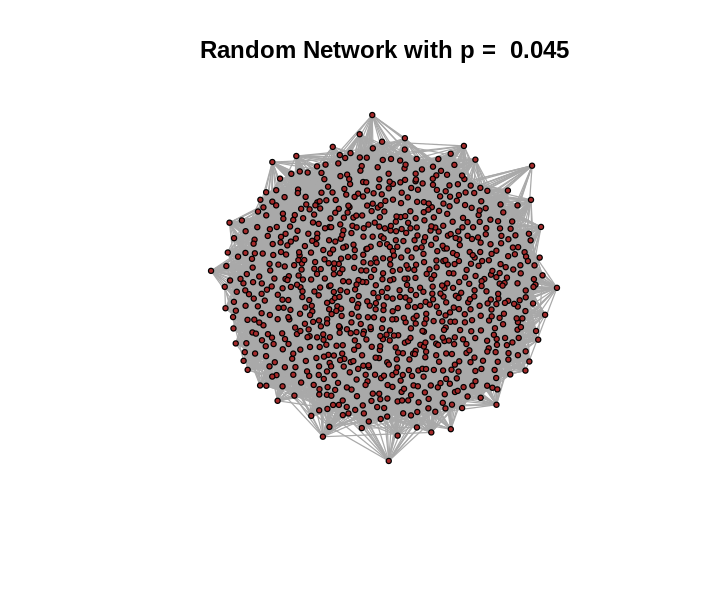

[1] "p =  0.1 is connected"
[1] "GCC Diameter = 3"


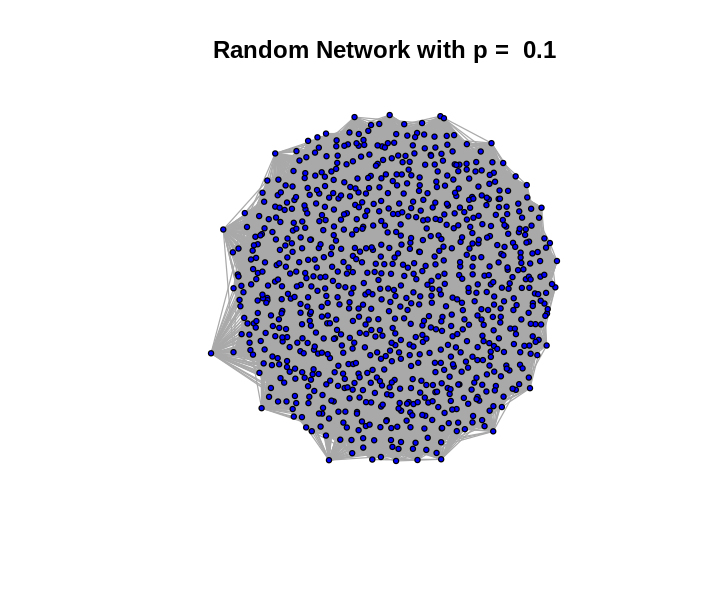

In [ ]:
for (i in 1:length(prob_values)) {
  clu <- components(networks[[i]])
  largest_clu <- which.max(clu$csize)
  gcc_verts <- which(clu$membership == largest_clu)

  plot(induced_subgraph(networks[[i]], gcc_verts), vertex.color=colors[i], vertex.size=3, vertex.label=NA, main=paste("Random Network with p = ", prob_values[i]))

  if (is_connected(networks[[i]])) {
    print (paste("p = ", prob_values[i], "is connected"))
  }
  else {
    print (paste("p = ", prob_values[i], "is NOT connected"))
  }

  # find GCC diameter
  di <- diameter(networks[[i]])
  print(paste("GCC Diameter =", di))
}

### c. Normalized GCC size
p = $O(\frac{1}{n})$ and p = $O(\frac{ln (n)} { n} )$:
For n = 900, sweep over values of p from 0 to a pmax that makes the network almost surely connected and create 100 random networks for each p. pmax should be roughly determined by yourself. Then scatter plot the normalized GCC sizes vs p. Plot a line of the average normalized GCC sizes for each p along with the scatter plot.

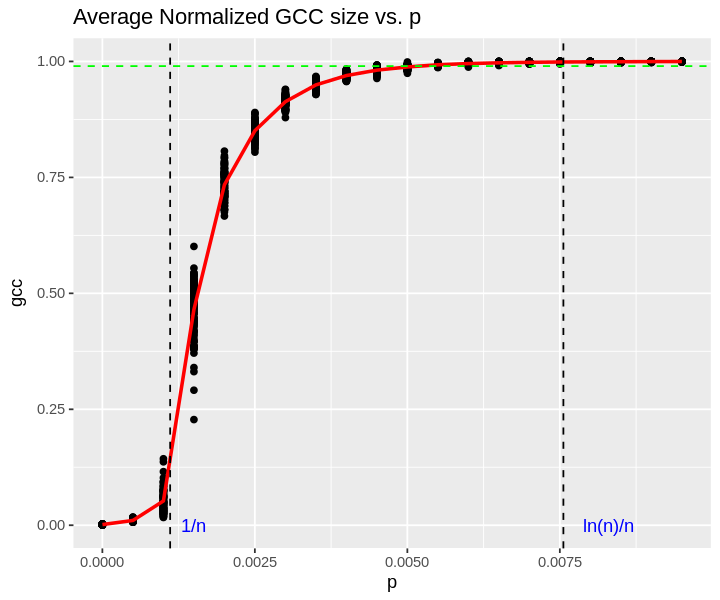

In [ ]:
p_max <- 0.01  # p_max > 0.0075
repetition <- 100

set.seed(NULL)
df <- data.frame()
for (p in seq(0.000001, p_max, by = 0.0005)) {
  for (i in 1:repetition) {
    g <- sample_gnp(n, p, directed = FALSE)
    gcc <- max(components(g)$csize)
    normalized_gcc <- gcc / n
    df <- rbind(df, list(p=p, gcc=normalized_gcc))
  }
}

ggplot(df, aes(x=p, y=gcc)) +
  geom_point() +
  stat_summary(fun = mean, geom = "line", color = "red", linewidth = 1) +
  geom_vline(xintercept = log(n)/n, linetype = "dashed", color = "black") +
  geom_vline(xintercept = 1/n, linetype = "dashed", color = "black") +
  geom_hline(yintercept = .99, linetype = "dashed", color = "green") +
  ggtitle("Average Normalized GCC size vs. p") +
  annotate("text", x = 0.0015, y = 0.0, label = "1/n", color = "blue") +
  annotate("text", x = 0.0083, y = 0.0, label = "ln(n)/n", color = "blue")


i) Empirically estimate the value of p where a giant connected component starts to emerge (define your criterion of “emergence”)? Do they match with theoretical values mentioned or derived in lectures?

$$\frac{1}{n}$$

$$n = 900$$

$$\frac{1}{900} = 0.001111$$

**Answer:** In the graph, we see that GCC starts to emerge at a p value of about 0.001. This is the point where our plotted curve starts sharply increasing.

Our criterion of "emergence" is the point at which the number of edges per node is greater than 1. This is calculated by the equation np>1 which we adjust to solve for the probability of a node with one edge, 1/n. This is thus the emergence point.

Yes, the value of p matches with the theoretical values mentioned in the lecture, which we show above (p = 0.001111).

ii) Empirically estimate the value of p where the giant connected component takes up over 99% of the nodes in almost every experiment.

$$\frac{ln(n)}{n}$$

$$n = 900$$

$$\frac{ln(900)}{900} = 0.0075582$$

**Answer:** Theoretically, the value of p where GCC takes up over 99% of the nodes is 0.0075582. In our graph, we see the line converge to around 0.99 at a p value of about 0.0075

In [ ]:
print(gcc)

[1] 900


### d. Avg Deg c = np = .5
i) Sweep over the number of nodes, n, ranging from 100 to 10000. Plot the expected size of the GCC of ER networks with n nodes and edge-formation probabilities p = c/n, as a function of n. What trend is observed?

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


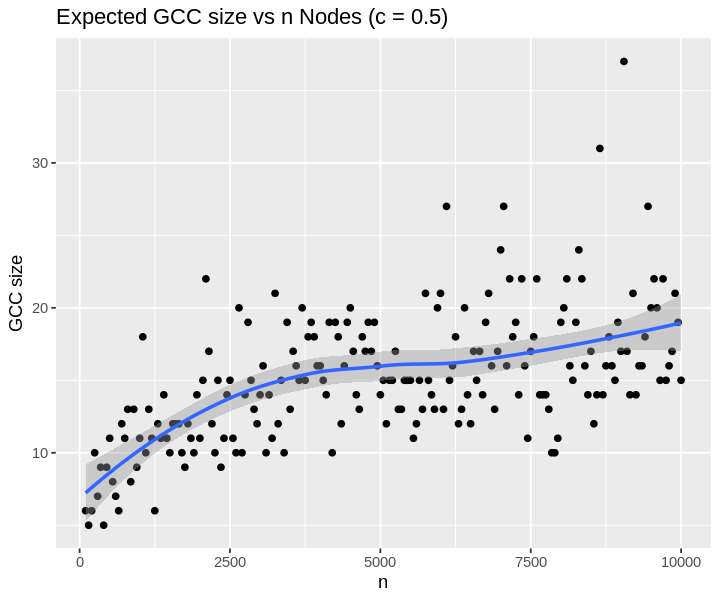

In [ ]:
c <- 0.5
df <- data.frame()

for (n in seq(100, 10000, by = 50)){
    p <- c/n
    g <- sample_gnp(n, p)
    gcc <- max(components(g)$csize)
    df <- rbind(df, data.frame(n = n, gcc = gcc))
}

ggplot(df, aes(x = n, y = gcc)) + geom_point() + geom_smooth() + ggtitle("Expected GCC size vs n Nodes (c = 0.5)") + ylab("GCC size")


**Answer:** As the number of nodes increases, the Giant Connected Component (GCC) gradually increases. Although the data points on the graph are fairly sparse, there is a noticeable trend as illustrated by the blue trend line.

ii) c = 1

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


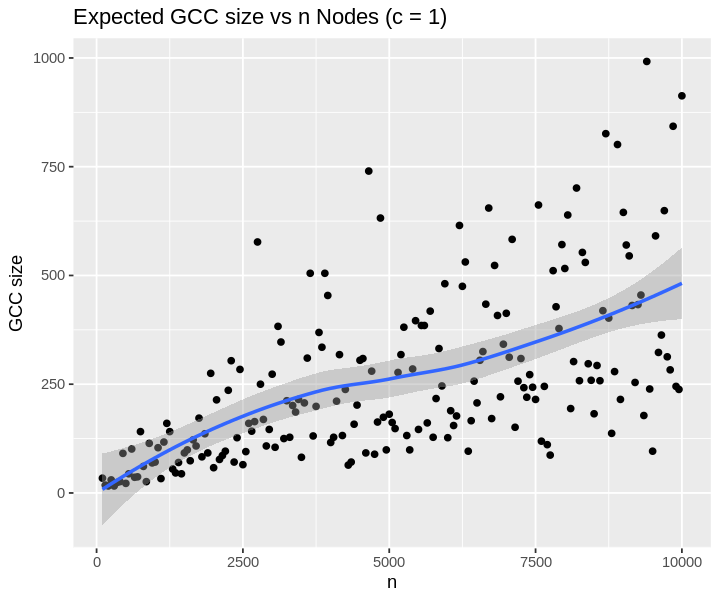

In [ ]:
c <- 1
df <- data.frame()

for (n in seq(100, 10000, by = 50)){
    p <- c/n
    g <- sample_gnp(n, p)
    gcc <- max(components(g)$csize)
    df <- rbind(df, data.frame(n = n, gcc = gcc))
}

ggplot(df, aes(x = n, y = gcc)) + geom_point() + geom_smooth() + ggtitle("Expected GCC size vs n Nodes (c = 1)") + ylab("GCC size")


**Answer:** Increasing the c value to 1 reduces the amount of variability and sparsity when the number of nodes is lower. As compared to the graph illustrating c=0.5, the graph above (with c=1) shows a similar gradually increasing trend line in blue. As the n increases, the datapoints stray farther away from the trend line. This is different than in the c=0.5 graph where regardless of the n value, the datapoints show a large variance from the trend line.

iii) c = 1.15, 1.25, 1.35

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


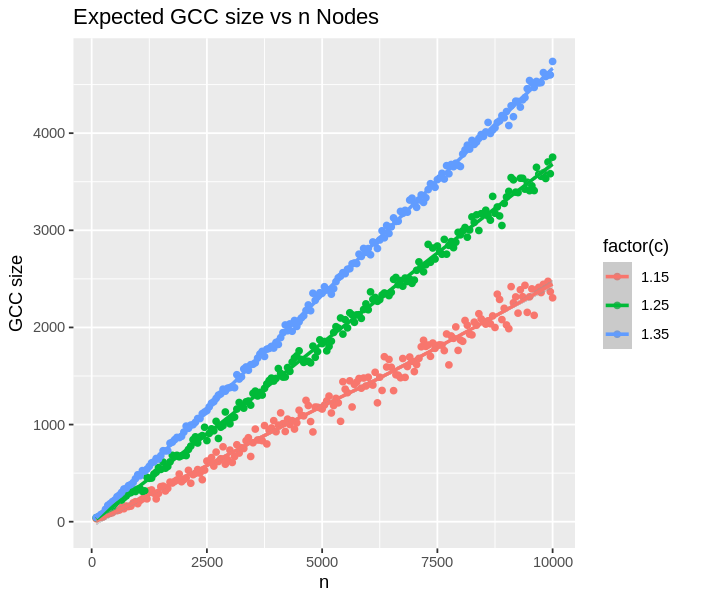

In [ ]:
c_val <- c(1.15, 1.25, 1.35)
df <- data.frame()
trials <- 10

for (c in c_val){
    for (n in seq(100, 10000, by = 50)){
        p <- c/n
        gcc <- numeric(trials)

        for(i in 1:trials){
            g <- sample_gnp(n, p)
            gcc[i] <- max(components(g)$csize)
        }
        avg_gcc <- mean(gcc)

        df <- rbind(df, data.frame(c = c, n = n, gcc = avg_gcc))
        }

}
ggplot(df, aes(x = n, y = gcc, color = factor(c))) + geom_point() + geom_smooth() + ggtitle("Expected GCC size vs n Nodes") + ylab("GCC size")

**Answer:** As seen in the chart above, as the c value increases, the slope of the datapoints increases. We observe a linear relationship. The trend line of the largest c value, c=1.35, is the steepest and the datapoints appear to be closer to the trend line than in the graph where c=1.15. Thus, this shows that as c increases, the slope of the datapoints increases and the variance of the datapoints to the trend line decreases. This means that with a larger c value, as n increases, the GCC increases more quickly than with a lower c-value.

## 2) Create networks using preferential attachment model




### a. Create an undirected network with n = 1050

with preferential attachment mode. where m = 1.

[1] TRUE

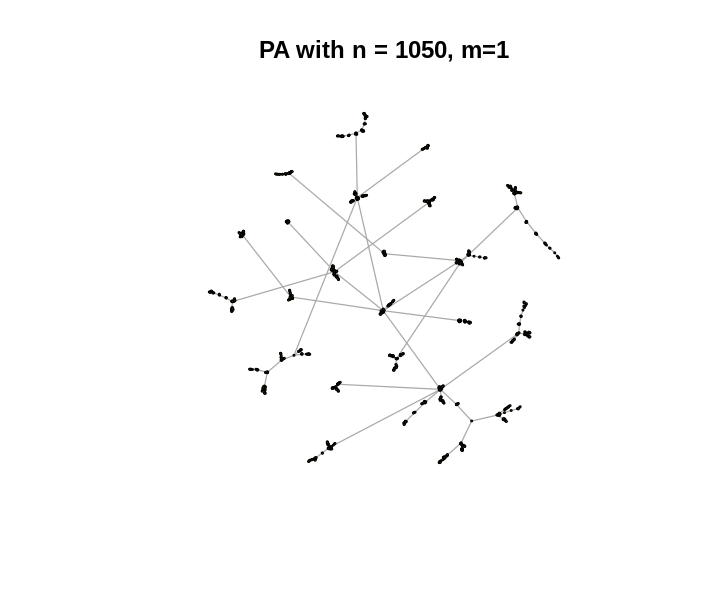

In [ ]:
# to generate a preferential attachment network with n=1050 nodes
n <- 1050

set.seed(2025)
# generate networks using sample_pa
pa_g <- sample_pa(n, m=1, directed = FALSE)

plot (pa_g, vertex.size=1, vertex.label=NA, main="PA with n = 1050, m=1")

is_connected(pa_g)


**Answer:** Yes, an undirected preferential attachment network established with these parameters is always connected.

### b. Find community structure

Use fast greedy method to find the community structure. Measure modularity. Define Assortativity. Compute Assortativity.

[1] "Modularity: 0.936047858916883"
[1] "Assortativity: -0.0565899933475765"


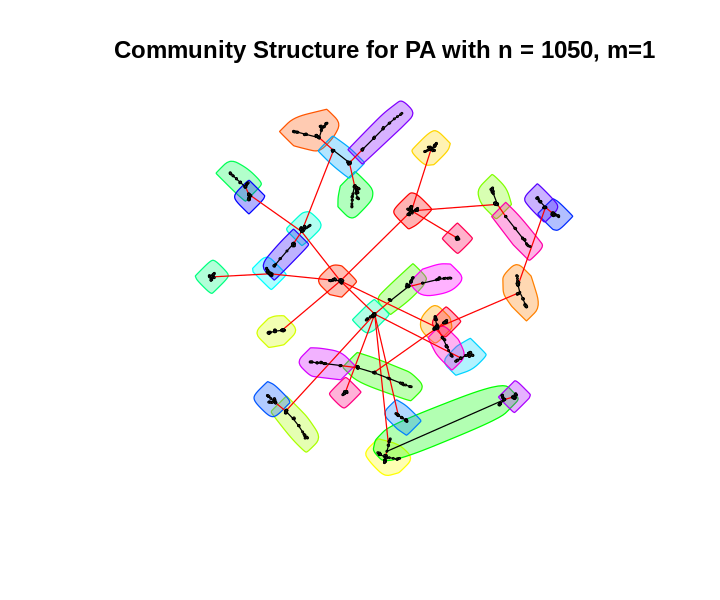

In [ ]:
# Fast greedy method to find community structure
community_pa <- cluster_fast_greedy(pa_g)
plot(community_pa, pa_g, vertex.size=1, vertex.label=NA, main="Community Structure for PA with n = 1050, m=1")

# Modularity
print(paste("Modularity:", modularity(community_pa)))

# Assortativity
print(paste("Assortativity:", assortativity_degree(pa_g)))

**Answer:** Define Assortativity: The assortativity coefficient measures the level of homophyly of the graph, based on some vertex labeling or values assigned to vertices. If the coefficient is high, that means that connected vertices tend to have the same labels or similar assigned values.

Modularity: 0.936047858916883

Assortativity: -0.0565899933475765

### c. Create a larger network with n = 10500

Try to generate a larger network with 10500 nodes using the same model. Compute modularity and assortativity. How is it compared to the smaller network's modularity?

[1] TRUE

[1] "Modularity: 0.979254674547955"
[1] "Assortativity: -0.0433975264676657"


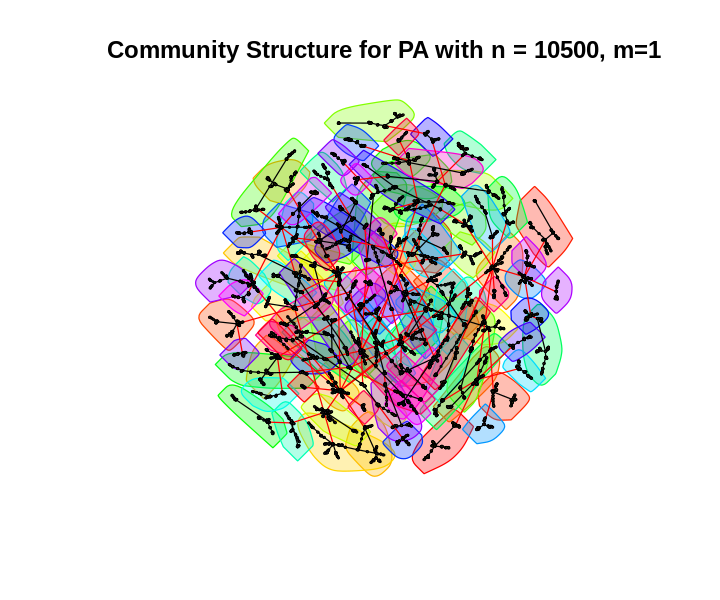

In [ ]:
# to generate a preferential attachment network with n=1050 nodes
n <- 10500

set.seed(2025)

# generate networks using sample_pa
pa_g2 <- sample_pa(n, m=1, directed = FALSE)
is_connected(pa_g2)

community_pa2 <- cluster_fast_greedy(pa_g2)
plot(community_pa2, pa_g2, vertex.size=1, vertex.label=NA, main="Community Structure for PA with n = 10500, m=1")

print(paste("Modularity:", modularity(community_pa2)))
print(paste("Assortativity:", assortativity_degree(pa_g2)))

Modularity (n = 10500): 0.979254674547955

Assortativity (n = 10500): -0.0433975264676657

**Answer:** When comparing the two networks above (n = 1050 and n=10500), we see that as the value of n increases, the modularity increases and the assortativity becomes less negative.

### d. Plot degree distribution
Plot the degree distribution in a log-log scale for both n = 1050, 10500, then estimate the slope of the plot using linear regression.

In [ ]:
# Calculate degree distribution and prepare data for plotting
prepare_degree_data <- function(graph) {
  n<-length(V(graph))
  deg <- degree(graph)
  deg_table <- as.data.frame(table(deg))
  colnames(deg_table) <- c("degree", "frequency")
  deg_table$degree <- as.numeric(as.character(deg_table$degree))
  deg_table$frequency <- as.numeric(deg_table$frequency)
  deg_table <- deg_table[deg_table$frequency > 0, ]
  deg_table$log_degree <- log10(deg_table$degree)
  deg_table$log_frequency <- log10(deg_table$frequency)
  deg_table$n <- n
  return(deg_table)
}

`geom_smooth()` using formula = 'y ~ x'


Slope for n = 1050: -2.328363 
Slope for n = 10500: -2.688647 


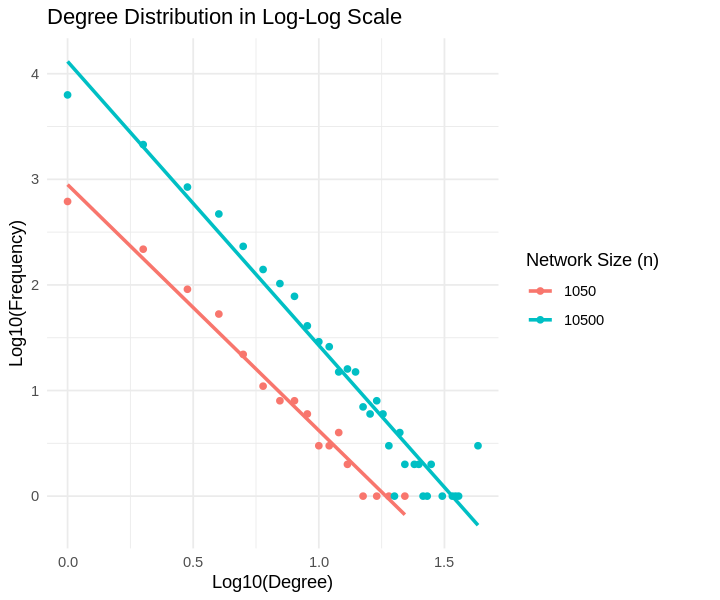

In [ ]:
data_1050 <- prepare_degree_data(pa_g)
data_10500 <- prepare_degree_data(pa_g2)

combined_data <- rbind(data_1050, data_10500)

# Plot the degree distribution in log-log scale
ggplot(combined_data, aes(x = log_degree, y = log_frequency, color = factor(n))) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Degree Distribution in Log-Log Scale",
       x = "Log10(Degree)",
       y = "Log10(Frequency)",
       color = "Network Size (n)") +
  theme_minimal()

# Estimate the slope of the plot using linear regression
lm_1050 <- lm(log_frequency ~ log_degree, data = data_1050)
lm_10500 <- lm(log_frequency ~ log_degree, data = data_10500)

cat("Slope for n = 1050:", coef(lm_1050)[2], "\n")
cat("Slope for n = 10500:", coef(lm_10500)[2], "\n")

**Answer:** Estimated Slopes

Slope for n = 1050: -2.328363

Slope for n = 10500: -2.688647

### e. Plot 2a and 2c in log-log scale

`geom_smooth()` using formula = 'y ~ x'


[1] "Slope: -1.182312193149"


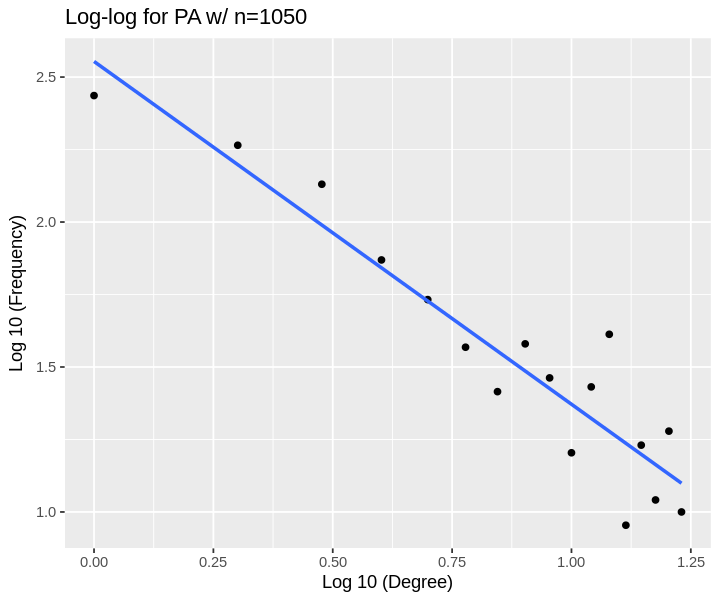

In [ ]:
# network with n = 1050
n_trials <- 1000
results <- numeric(n_trials)

for (i in 1:n_trials){
    node_i <- sample(V(pa_g), size = 1)
    neighbors_i <- neighbors(pa_g, node_i)
    node_j <- sample(neighbors_i, size = 1)

    results[i] <- degree(pa_g, node_j)
}

freqs <- as.data.frame(table(results))
freqs[,1] <- as.numeric(freqs[,1])
colnames(freqs) <- c("degrees", "frequency")
freqs$log_degree <- log10(freqs$degrees)
freqs$log_frequency <- log10(freqs$frequency)

ggplot(freqs, aes(x = log_degree, y = log_frequency)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE) +
    labs(x = "Log 10 (Degree)", y = "Log 10 (Frequency)", title = "Log-log for PA w/ n=1050")

# calculate slope
lm <- lm(log_frequency ~ log_degree, data = freqs)
print(paste("Slope:", coef(lm)[2]))

`geom_smooth()` using formula = 'y ~ x'


[1] "Slope: -1.67793448575573"


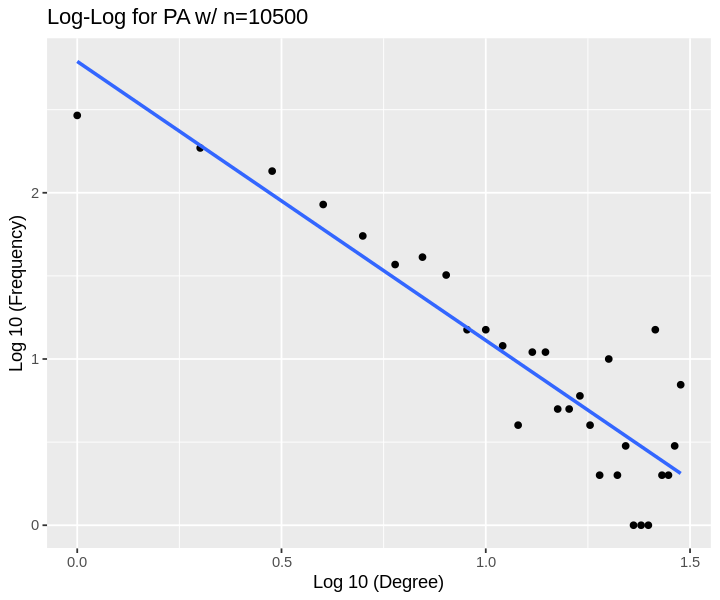

In [ ]:
# network with n = 10500
n_trials <- 1000
results <- numeric(n_trials)

for (i in 1:n_trials){
    node_i <- sample(V(pa_g2), size = 1)
    neighbors_i <- neighbors(pa_g2, node_i)
    node_j <- sample(neighbors_i, size = 1)

    results[i] <- degree(pa_g2, node_j)
}

freqs <- as.data.frame(table(results))
freqs[,1] <- as.numeric(freqs[,1])
colnames(freqs) <- c("degrees", "frequency")
freqs$log_degree <- log10(freqs$degrees)
freqs$log_frequency <- log10(freqs$frequency)

ggplot(freqs, aes(x = log_degree, y = log_frequency)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE) +
    labs(x = "Log 10 (Degree)", y = "Log 10 (Frequency)", title = "Log-Log for PA w/ n=10500")

# calculate slope
lm <- lm(log_frequency ~ log_degree, data = freqs)
print(paste("Slope:", coef(lm)[2]))

Is the distribution linear in the log-log scale? If so, what is the slope? How does this differ from the node degree distribution?

**Answer:** The distribution of degrees is linear for both networks with 1050 nodes and 10500 nodes. The calculated slopes are outlined in the following table:

| n | slope from part d | slope from part e |
|---|---|---|
| 1050 | -2.328363 | -1.212214  |
| 10500 | -2.688647 | -1.598572 |

As seen, the absolute value of the slopes of the degree distributions from part d are significantly larger than the slopes of the observed distribution of degrees identified in part e. Since these slopes are negative, this means that the log-log degree distribution has a steeper negative slope and as the log of degree increases, the log frequency decreases faster than that of the slopes calculated in part e. For example, for a network of 1050 nodes, the slope of the degree distribution was found to be ~ -2.3 while the slope of the degrees of a random sample of nodes is ~ -1.2.

### f. Find expected degree

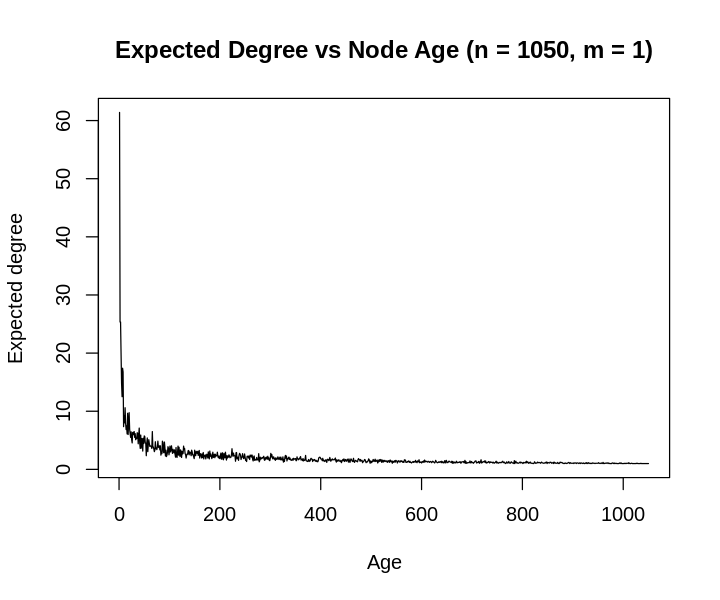

In [ ]:
num_trials <- 20
degrees <- list()
for (i in 1:num_trials){
    pa_g <- sample_pa(n = 1050, m = 1)
    degrees[[i]] <- degree(pa_g)
}
expected_degrees <- do.call(cbind, degrees)
plot(rowMeans(expected_degrees), type = 'l', xlab = "Age", ylab = "Expected degree", main = "Expected Degree vs Node Age (n = 1050, m = 1)")

### g. Repeat using m = 2 & 6

#### m = 2


In [ ]:
# part a
n <- 1050
set.seed(2025)

pa_g <- sample_pa(n, m=2, directed = FALSE)
if (is_connected(pa_g)){
    print("The network (n = 1050, m = 2) is connected")
}

# part b
# Use fast greedy method to find the community structure.
community_pa <- cluster_fast_greedy(pa_g)

print(paste("Modularity: ", modularity(community_pa)))
print(paste("Assortativity: ", assortativity_degree(pa_g)))

# part c
n <- 10500
pa_g2 <- sample_pa(n, m=2, directed = FALSE)

if (is_connected(pa_g2)){
    print("The network (n = 10500, m = 2) is connected")
}
community_pa2 <- cluster_fast_greedy(pa_g2)
print(paste("Modularity: ", modularity(community_pa2)))
print(paste("Assortativity: ", assortativity_degree(pa_g2)))

[1] "The network (n = 1050, m = 2) is connected"
[1] "Modularity:  0.525042814984915"
[1] "Assortativity:  -0.0200870259414495"
[1] "The network (n = 10500, m = 2) is connected"
[1] "Modularity:  0.53133978011392"
[1] "Assortativity:  -0.0105969128289061"


`geom_smooth()` using formula = 'y ~ x'


Slope for n = 1050: -2.108067 
Slope for n = 10500: -2.333298 


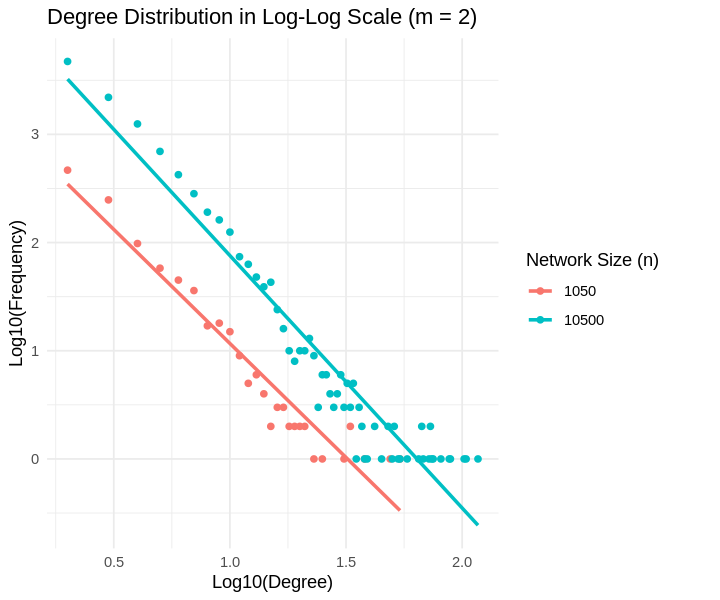

In [ ]:
# part d
# Plot degree distribution in a log-log scale for n = 1050 and n = 10500
data_1050 <- prepare_degree_data(pa_g)
data_10500 <- prepare_degree_data(pa_g2)

combined_data <- rbind(data_1050, data_10500)

# Plot the degree distribution in log-log scale
ggplot(combined_data, aes(x = log_degree, y = log_frequency, color = factor(n))) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Degree Distribution in Log-Log Scale (m = 2)",
       x = "Log10(Degree)",
       y = "Log10(Frequency)",
       color = "Network Size (n)") +
  theme_minimal()

# Estimate the slope of the plot using linear regression
lm_1050 <- lm(log_frequency ~ log_degree, data = data_1050)
lm_10500 <- lm(log_frequency ~ log_degree, data = data_10500)

cat("Slope for n = 1050:", coef(lm_1050)[2], "\n")
cat("Slope for n = 10500:", coef(lm_10500)[2], "\n")

`geom_smooth()` using formula = 'y ~ x'


log_degree 
 -1.077166 


`geom_smooth()` using formula = 'y ~ x'


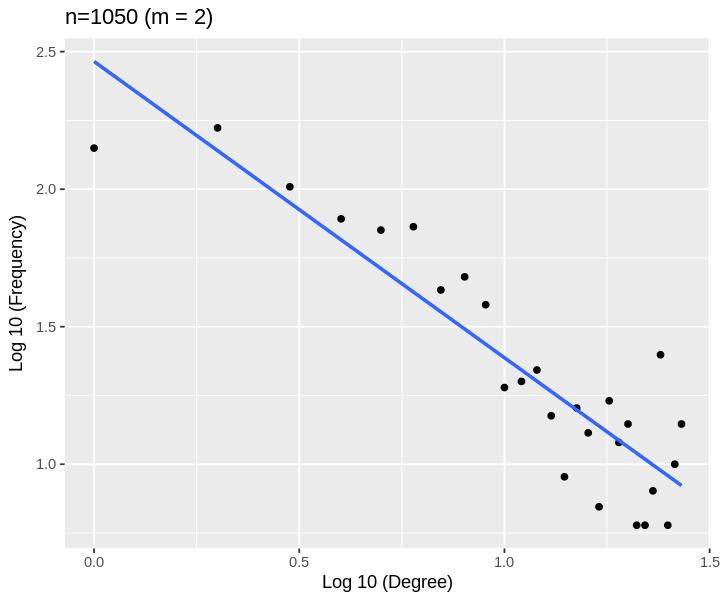

[1] "Slope: -1.48773559152765"


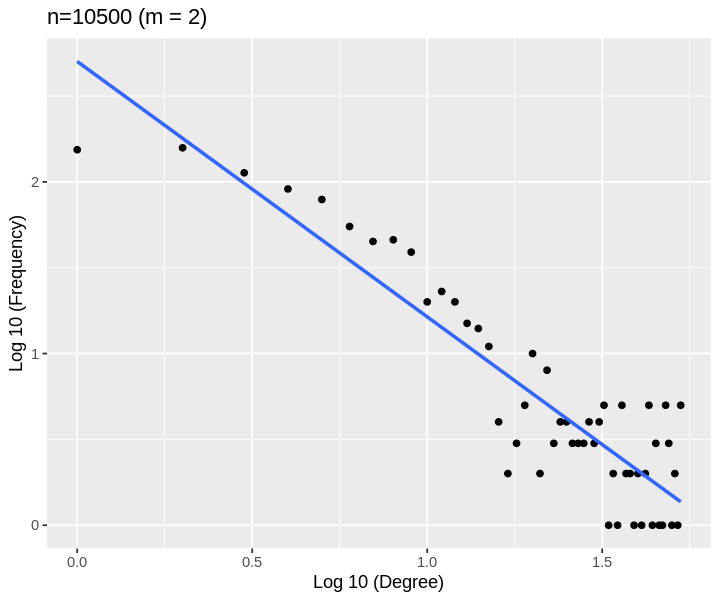

In [ ]:
# part e
# network with n = 1050
n_trials <- 1000
results <- numeric(n_trials)

for (i in 1:n_trials){
    node_i <- sample(V(pa_g), size = 1)
    neighbors_i <- neighbors(pa_g, node_i)
    node_j <- sample(neighbors_i, size = 1)

    results[i] <- degree(pa_g, node_j)
}

freqs <- as.data.frame(table(results))
freqs[,1] <- as.numeric(freqs[,1])
colnames(freqs) <- c("degrees", "frequency")
freqs$log_degree <- log10(freqs$degrees)
freqs$log_frequency <- log10(freqs$frequency)

ggplot(freqs, aes(x = log_degree, y = log_frequency)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE) +
    labs(x = "Log 10 (Degree)", y = "Log 10 (Frequency)", title = "n=1050 (m = 2)")

# calculate slope
lm <- lm(log_frequency ~ log_degree, data = freqs)
print (coef(lm)[2])

# network with n = 10500
n_trials <- 1000
results <- numeric(n_trials)

for (i in 1:n_trials){
    node_i <- sample(V(pa_g2), size = 1)
    neighbors_i <- neighbors(pa_g2, node_i)
    node_j <- sample(neighbors_i, size = 1)

    results[i] <- degree(pa_g2, node_j)
}

freqs <- as.data.frame(table(results))
freqs[,1] <- as.numeric(freqs[,1])
colnames(freqs) <- c("degrees", "frequency")
freqs$log_degree <- log10(freqs$degrees)
freqs$log_frequency <- log10(freqs$frequency)

ggplot(freqs, aes(x = log_degree, y = log_frequency)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE) +
    labs(x = "Log 10 (Degree)", y = "Log 10 (Frequency)", title = "n=10500 (m = 2)")

# calculate slope
lm <- lm(log_frequency ~ log_degree, data = freqs)
print(paste("Slope:", coef(lm)[2]))

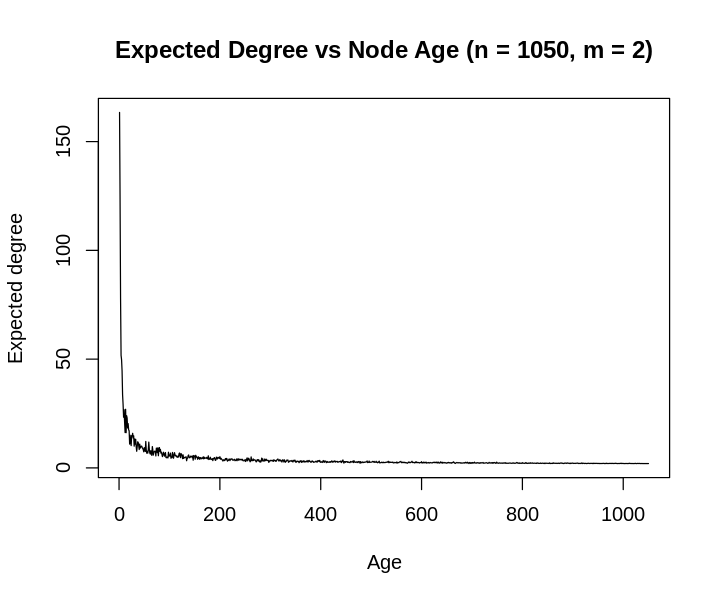

In [ ]:
# part f
num_trials <- 20
degrees <- list()
for (i in 1:num_trials){
    pa_g <- sample_pa(n = 1050, m = 2)
    degrees[[i]] <- degree(pa_g)
}
expected_degrees <- do.call(cbind, degrees)
plot(rowMeans(expected_degrees), type = 'l', xlab = "Age", ylab = "Expected degree", main = "Expected Degree vs Node Age (n = 1050, m = 2)")

#### m = 6


In [ ]:
# part a
n <- 1050
set.seed(2025)

pa_g <- sample_pa(n, m = 6, directed = FALSE)
if (is_connected(pa_g)){
    print("The network (n = 1050, m = 6) is connected")
}

# part b
# Use fast greedy method to find the community structure.
community_pa <- cluster_fast_greedy(pa_g)

print(paste("Modularity: ", modularity(community_pa)))
print(paste("Assortativity: ", assortativity_degree(pa_g)))

# part c
n <- 10500
pa_g2 <- sample_pa(n, m = 6, directed = FALSE)

if (is_connected(pa_g2)){
    print("The network (n = 10500, m = 6) is connected")
}
community_pa2 <- cluster_fast_greedy(pa_g2)
print(paste("Modularity: ", modularity(community_pa2)))
print(paste("Assortativity: ", assortativity_degree(pa_g2)))

[1] "The network (n = 1050, m = 6) is connected"
[1] "Modularity:  0.251831495490483"
[1] "Assortativity:  -0.0212666831608282"
[1] "The network (n = 10500, m = 6) is connected"
[1] "Modularity:  0.245493380756595"
[1] "Assortativity:  -0.000782878528107161"


`geom_smooth()` using formula = 'y ~ x'


Slope for n = 1050: -1.9655 
Slope for n = 10500: -2.145802 


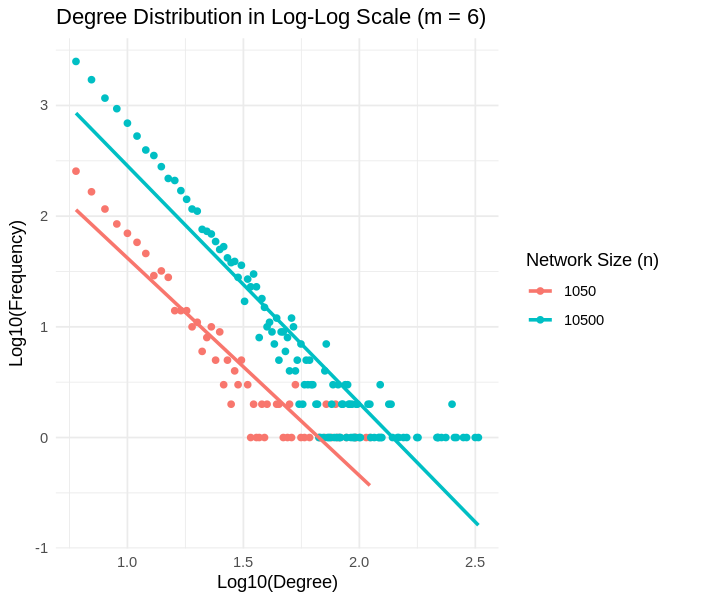

In [ ]:
# part d
# Plot degree distribution in a log-log scale for n = 1050 and n = 10500
data_1050 <- prepare_degree_data(pa_g)
data_10500 <- prepare_degree_data(pa_g2)

combined_data <- rbind(data_1050, data_10500)

# Plot the degree distribution in log-log scale
ggplot(combined_data, aes(x = log_degree, y = log_frequency, color = factor(n))) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Degree Distribution in Log-Log Scale (m = 6)",
       x = "Log10(Degree)",
       y = "Log10(Frequency)",
       color = "Network Size (n)") +
  theme_minimal()

# Estimate the slope of the plot using linear regression
lm_1050 <- lm(log_frequency ~ log_degree, data = data_1050)
lm_10500 <- lm(log_frequency ~ log_degree, data = data_10500)

cat("Slope for n = 1050:", coef(lm_1050)[2], "\n")
cat("Slope for n = 10500:", coef(lm_10500)[2], "\n")

`geom_smooth()` using formula = 'y ~ x'


log_degree 
-0.9551487 


`geom_smooth()` using formula = 'y ~ x'


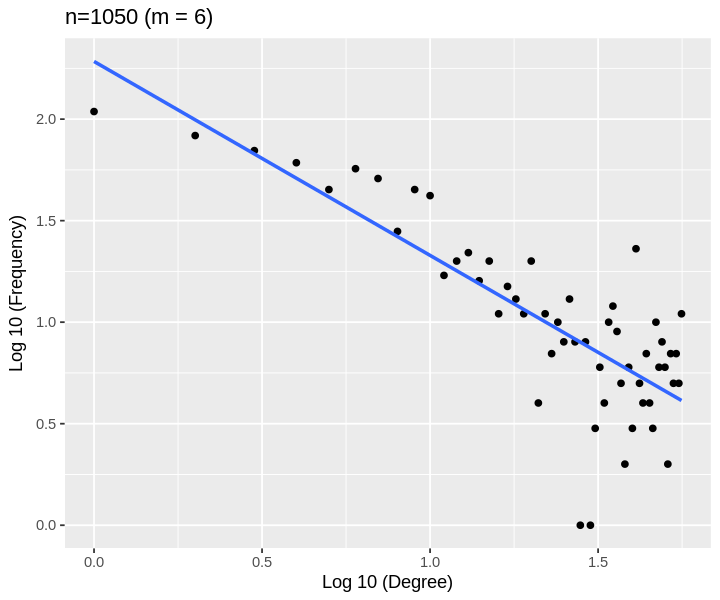

[1] "Slope: -1.16192638548117"


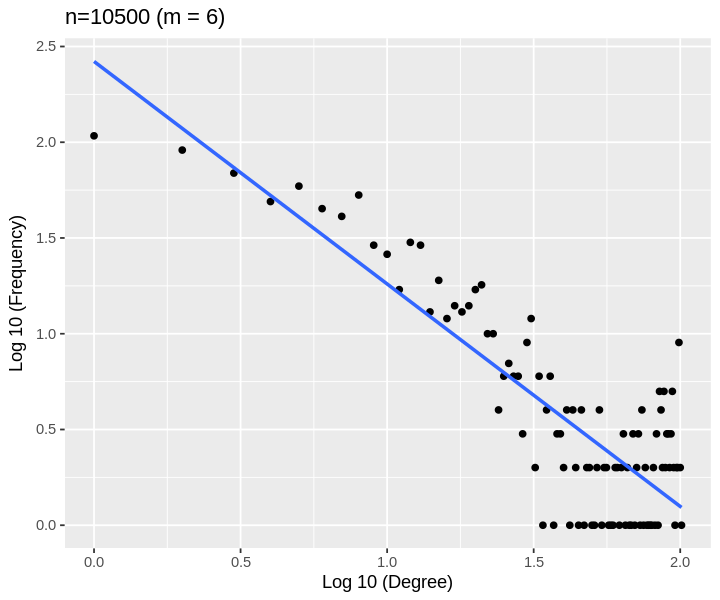

In [ ]:
# part e
# network with n = 1050
n_trials <- 1000
results <- numeric(n_trials)

for (i in 1:n_trials){
    node_i <- sample(V(pa_g), size = 1)
    neighbors_i <- neighbors(pa_g, node_i)
    node_j <- sample(neighbors_i, size = 1)

    results[i] <- degree(pa_g, node_j)
}

freqs <- as.data.frame(table(results))
freqs[,1] <- as.numeric(freqs[,1])
colnames(freqs) <- c("degrees", "frequency")
freqs$log_degree <- log10(freqs$degrees)
freqs$log_frequency <- log10(freqs$frequency)

ggplot(freqs, aes(x = log_degree, y = log_frequency)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE) +
    labs(x = "Log 10 (Degree)", y = "Log 10 (Frequency)", title = "n=1050 (m = 6)")

# calculate slope
lm <- lm(log_frequency ~ log_degree, data = freqs)
print (coef(lm)[2])

# network with n = 10500
n_trials <- 1000
results <- numeric(n_trials)

for (i in 1:n_trials){
    node_i <- sample(V(pa_g2), size = 1)
    neighbors_i <- neighbors(pa_g2, node_i)
    node_j <- sample(neighbors_i, size = 1)

    results[i] <- degree(pa_g2, node_j)
}

freqs <- as.data.frame(table(results))
freqs[,1] <- as.numeric(freqs[,1])
colnames(freqs) <- c("degrees", "frequency")
freqs$log_degree <- log10(freqs$degrees)
freqs$log_frequency <- log10(freqs$frequency)

ggplot(freqs, aes(x = log_degree, y = log_frequency)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE) +
    labs(x = "Log 10 (Degree)", y = "Log 10 (Frequency)", title = "n=10500 (m = 6)")

# calculate slope
lm <- lm(log_frequency ~ log_degree, data = freqs)
print(paste("Slope:", coef(lm)[2]))

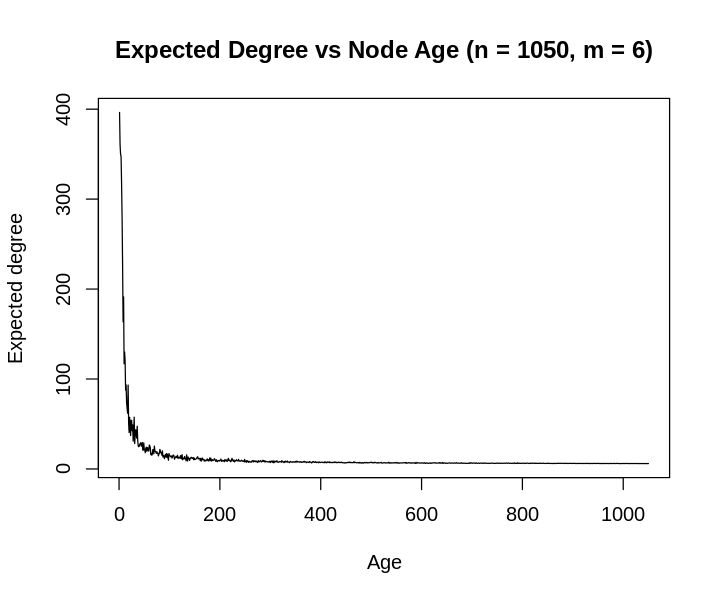

In [ ]:
# part f
num_trials <- 20
degrees <- list()
for (i in 1:num_trials){
    pa_g <- sample_pa(n = 1050, m = 6)
    degrees[[i]] <- degree(pa_g)
}
expected_degrees <- do.call(cbind, degrees)
plot(rowMeans(expected_degrees), type = 'l', xlab = "Age", ylab = "Expected degree", main = "Expected Degree vs Node Age (n = 1050, m = 6)")

**Answer:** As m increases, the modularity decreases. As m increases, the absolute value of the slope of the degree distributions for both the degree distribution and the neighboring node degree distributions decreases in value. Since the slope values are negative, we see that the slope becomes less steep as m increases. With a consistent m value, as the number of nodes increases, the slope becomes steeper and the assortativity is smaller. These trends can be seen in the table below.

Summary of results with m = 1, m = 2, and m = 6.

| m | n | is_connected | modularity | assortativity | slope of log-log for part d | slope of log-log for part e |
|---|---|--------------|------------|---------------|-----------------------------|-----------------------------|
| 1 | 1050 | True | 0.9360 | -0.0566 | -2.3283 | -1.2101 |
| 2 | 1050 | True | 0.5250 | -0.0201 | -2.1080 | -1.0772 |
| 6 | 1050 | True | 0.2518 | -0.0213 | -1.9655 | -0.8723 |
| 1 | 10500 | True | 0.9793 | -0.0434 | -2.6886 | -1.6576 |
| 2 | 10500 | True | 0.5313 | -0.0106 | -2.3333 | -1.4876 |
| 6 | 10500 | True | 0.2455 | -0.0008 | -2.1458 | -1.1619 |

### h. Plot deg seq of network n = 1050, m = 1

Take its degree sequence and create a new network with the same degree sequence, through stub-matching procedure. Plot both networks, mark communities on their plots, and measure their modularity. Compare the two procedures for creating random power-law networks.

Useful functions: sample_degseq, cluster_walktrap

Warning message:
“The `method` argument of `sample_degseq()` must be configuration instead of
simple as of igraph 2.1.0.”


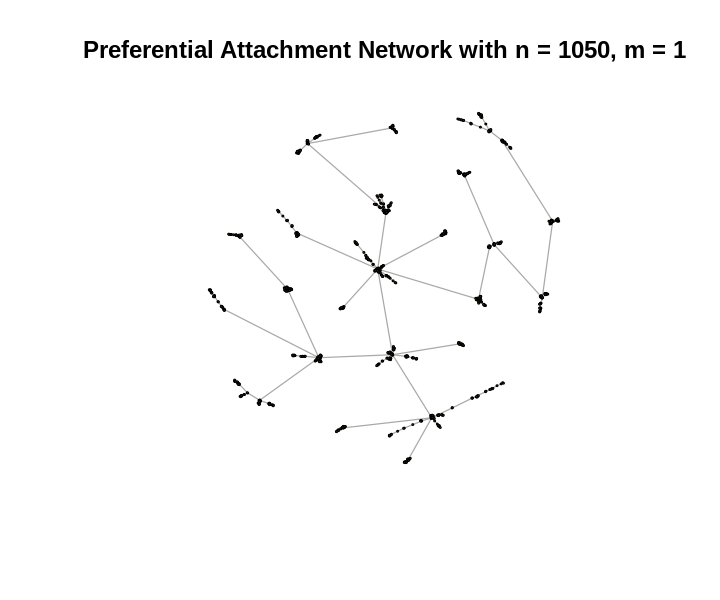

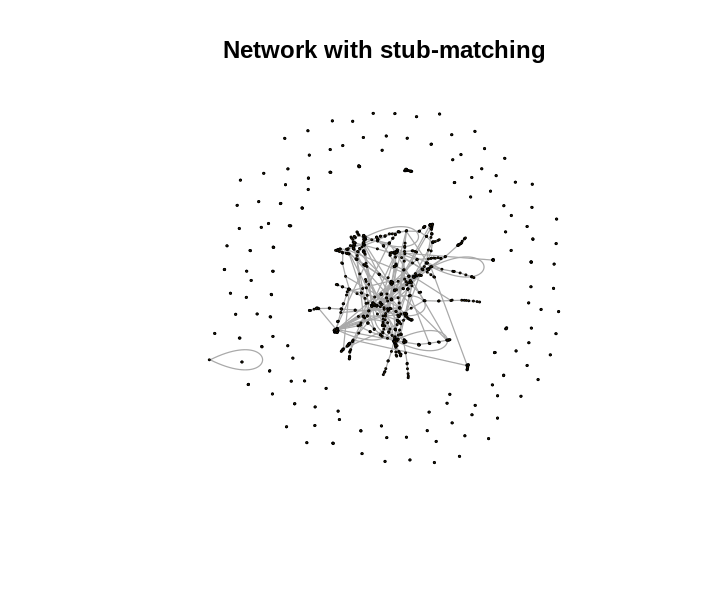

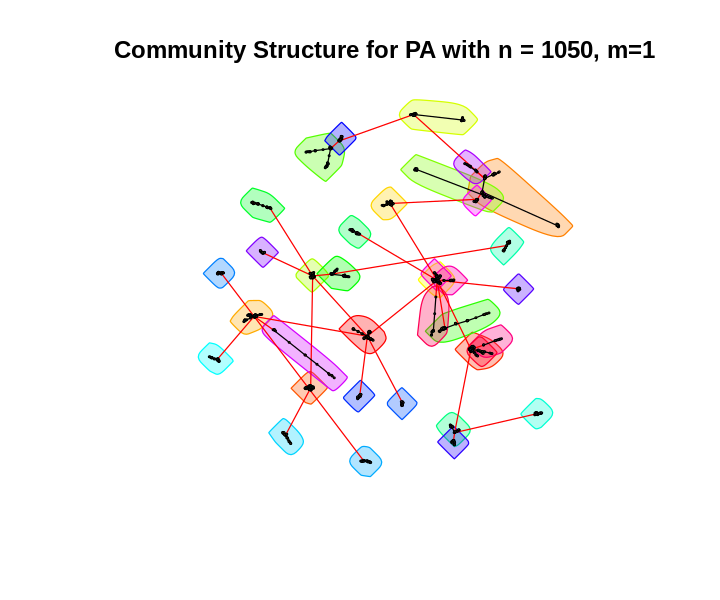

[1] "Modularity of PA network:  0.930063676786913"
[1] "Modularity of stub-matching network:  0.732952351006588"


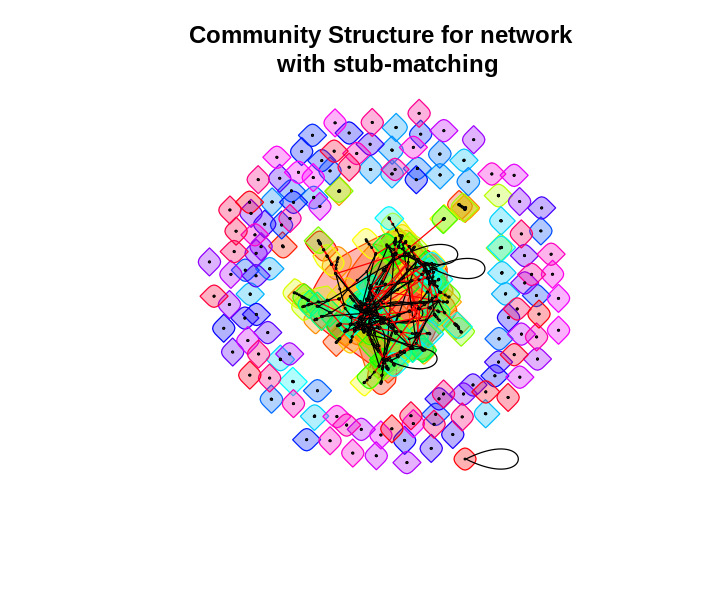

In [ ]:
# generate a preferential attachment network with n = 1050, m = 1
pa_g3 <- sample_pa(n = 1050, m = 1, directed = FALSE)
# take its degree sequence
deg_seq_pa <- degree(pa_g3)
# create a new network with stub-matching
pa_g4 <- sample_degseq(deg_seq_pa, method = "simple")

# plot both networks
plot(pa_g3, vertex.size=1, vertex.label=NA, main="Preferential Attachment Network with n = 1050, m = 1")
plot(pa_g4, vertex.size=1, vertex.label=NA, main="Network with stub-matching")

# measure modularity
community_pa3 <- cluster_fast_greedy(pa_g3)

# walktrap community detection
community_pa4 <- cluster_walktrap(pa_g4) # Fast greedy community detection works only on graphs without multi-edges. Invalid value

# plot communities
plot(community_pa3, pa_g3, vertex.size=1, vertex.label=NA, main="Community Structure for PA with n = 1050, m=1")
plot(community_pa4, pa_g4, vertex.size=1, vertex.label=NA, main="Community Structure for network \n with stub-matching")

print(paste("Modularity of PA network: ", modularity(community_pa3)))
print(paste("Modularity of stub-matching network: ", modularity(community_pa4)))

In [ ]:
#PA Network
paste("GCC (PA Network):", max(components(pa_g3)$csize))
paste("Diameter (PA Netork):", diameter(pa_g3))

#Stub-matching Network
paste("GCC (SM Network):", max(components(pa_g4)$csize))
paste("Diameter (SM Netork):", diameter(pa_g4))

[1] "GCC (PA Network): 1050"

[1] "Diameter (PA Netork): 23"

[1] "GCC (SM Network): 727"

[1] "Diameter (SM Netork): 16"

**Answer:** The stub-matching created network and the orignial preferential attachment (PA) network have the same degree sequence. The original PA network has a GCC of 1050 and the stub-matching network has a GCC of 771.

## 3) Create preferential attachment model with age penalty



### a. Each time a new vertex is added, it creates m links to old vertices and the probability that an old vertex is cited depends on its degree (preferential attachment) and age.
$ P[i] \sim (ck_i^\alpha + a) (dl_i^\beta + b) $
Produce such an undirected network with 1050 nodes and parameters m = 1,α = 1, β = −1, and a = c = d = 1, b = 0. Plot the degree distribution.
$ ie. P[i] \sim (k_i + 1) (l_i^{-1} ) $


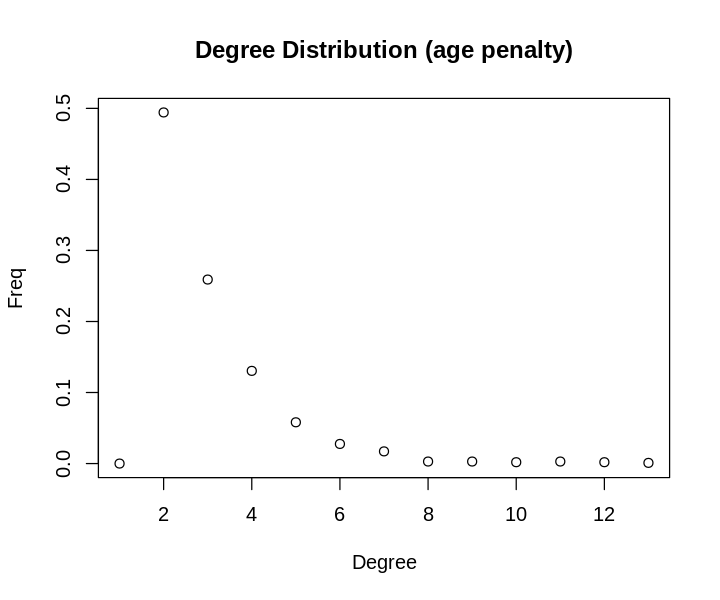

In [ ]:
pa_age_PA <- sample_pa_age(n=1050, m=1,
    directed= FALSE, pa.exp=1,
    aging.exp=-1, zero.deg.appeal=1,
    zero.age.appeal=0, deg.coef=1, age.coef=1)

deg_dist_PA <- degree_distribution(pa_age_PA)
plot(deg_dist_PA, xlab="Degree", ylab="Freq", main="Degree Distribution (age penalty)")
fit <- fit_power_law(degree(pa_age_PA), implementation = "plfit")

What is the Power Law Exponent?

In [ ]:
print(paste("Power Law Exponent:", fit$alpha))

[1] "Power Law Exponent: 4.61958242951365"


**Answer:** Power Law Exponent: 4.54736029048426

### b. Find community structure

[1] "Modularity of PA with age panelty: 0.936554946787578"


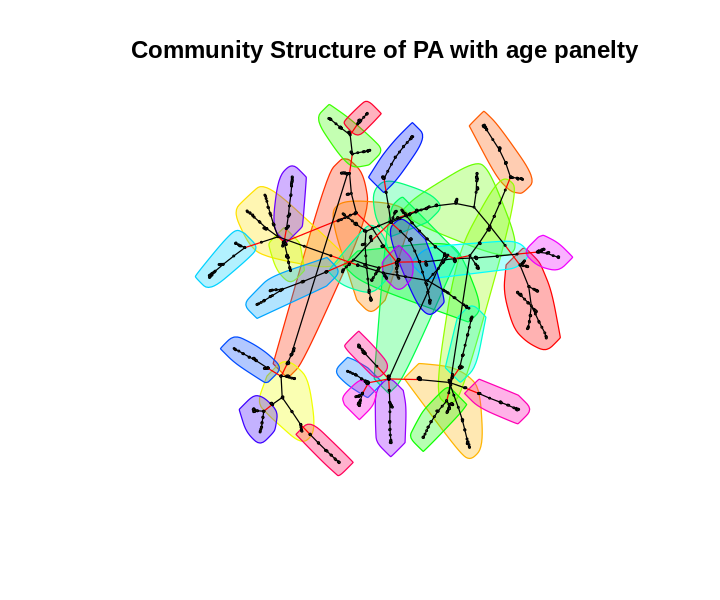

In [ ]:
# fast greedy method to find the community structure.
community_pa_PA <- cluster_fast_greedy(pa_age_PA)
plot(community_pa_PA, pa_age_PA, vertex.size=1, vertex.label=NA, main="Community Structure of PA with age panelty")

# Measure modularity.
mod_PA <- modularity(community_pa_PA)
print(paste("Modularity of PA with age panelty:", mod_PA))

**Answer:** Modularity of PA with age panelty: 0.936835299131862

# B. Random Walk on Networks

## 1) Random Walk on Erd ̈os-R ́enyi networks

In [ ]:
install.packages("igraph")
install.packages("pacman")
pacman::p_load(Matrix)
install.packages('pracma')
library('igraph')
library('Matrix')
library('pracma')
library('ggplot2')

options(repr.plot.width=6, repr.plot.height=5)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Attaching package: ‘pracma’


The following objects are masked from ‘package:Matrix’:

    expm, lu, tril, triu




In [ ]:
create_transition_matrix = function (g){

    # WARNING: make sure your graph is connected (you might input GCC of your graph)

    vs = V(g)
    n = vcount(g)
    adj = as_adjacency_matrix(g)
    adj[diag(rowSums(adj) == 0)] = 1  # handle if the user is using the function for networks with isolated nodes by creating self-edges
    z = matrix(rowSums(adj, , 1))

    transition_matrix = adj / repmat(z, 1, n)  # normalize to get probabilities

    return(transition_matrix)
}

In [ ]:
random_walk = function (g, num_steps, start_node, transition_matrix = NULL){
    if(is.null(transition_matrix))
        transition_matrix = create_transition_matrix(g)

    v = as.integer(start_node)
    for(i in 1:num_steps){
        # fprintf('Step %d: %d\n', i, v)  # COMMENT THIS
        PMF = transition_matrix[v, ]
        v = sample(1:vcount(g), 1, prob = PMF)
    }

    return(v)
}

### a) Create an undirected random network with 900 nodes, and the probability p for drawing an edge between any pair of nodes equal to 0.015.

In [ ]:
set.seed(0)
g = sample_gnp(900, 0.015)

is_connected(g)

[1] TRUE

### b) Measure the average distance (defined as the shortest path length) ⟨s(t)⟩ of the walker from his starting
point at step t. Also, measure the variance $σ^2(t) = ⟨(s(t) − ⟨s(t)⟩)^2⟩$ of this distance.
Plot ⟨s(t)⟩ v.s. t and $σ^2(t)$ v.s. t.

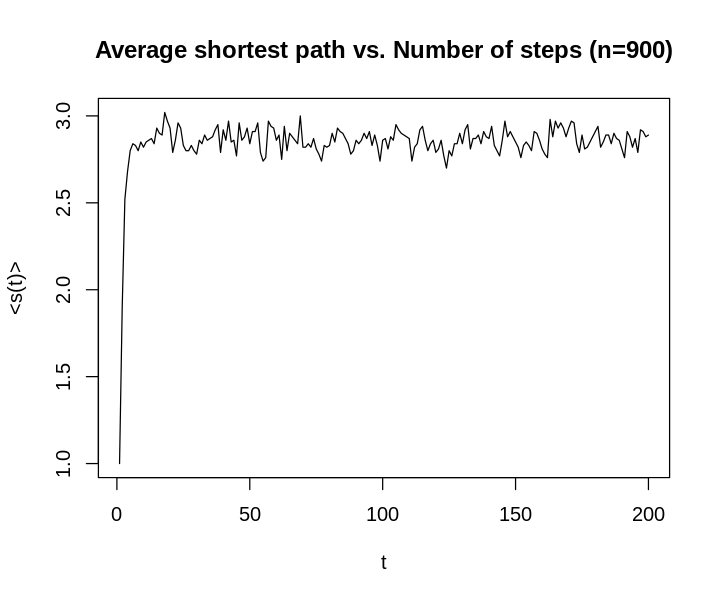

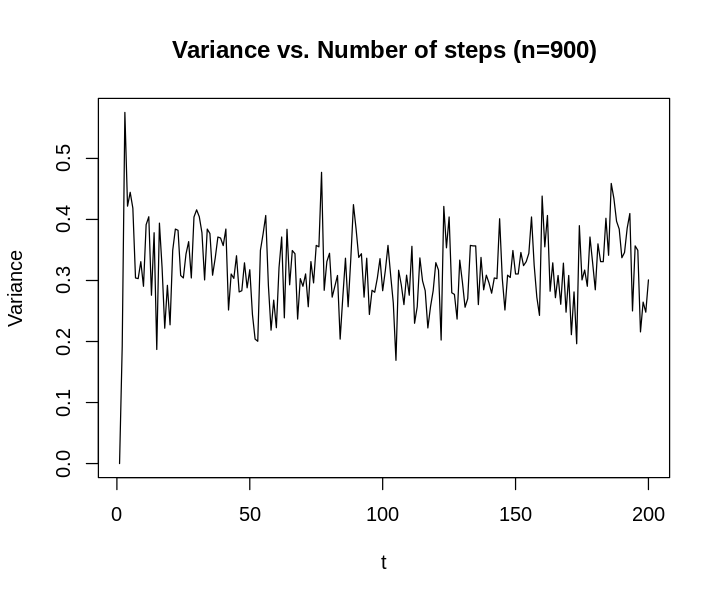

In [ ]:
st <- c()
steps <- 200
num_trials <- 100
all_nodes <- c()
st_all <- list()
avg_all_st <- c()
var_values <- c()

for (n in 1: num_trials){
  start_node <- sample(V(g), 1)
  v_last <- start_node
    for(i in 1:steps){
        v_last <- random_walk(g, 1, v_last)

        edges_walked <- distances(g, start_node, v_last)

        st[i] <- edges_walked
        all_nodes <- append(all_nodes, v_last)
    }

    st_all[[n]] <- st
}

for (i in 1:steps){
  st_i <- sapply(st_all, function(x) x[i])
  avg_all_st[i] <- mean(st_i)
  var_values[i] <- var(st_i)
}

plot(1:length(avg_all_st), avg_all_st, xlab="t", ylab="<s(t)>", main="Average shortest path vs. Number of steps (n=900)", cex=0.5, type = 'l')
plot(1:length(var_values), var_values, xlab="t", ylab="Variance", main="Variance vs. Number of steps (n=900)", cex=0.5, type='l')

### c) Measure the degree distribution of the nodes reach at the end of the random walk

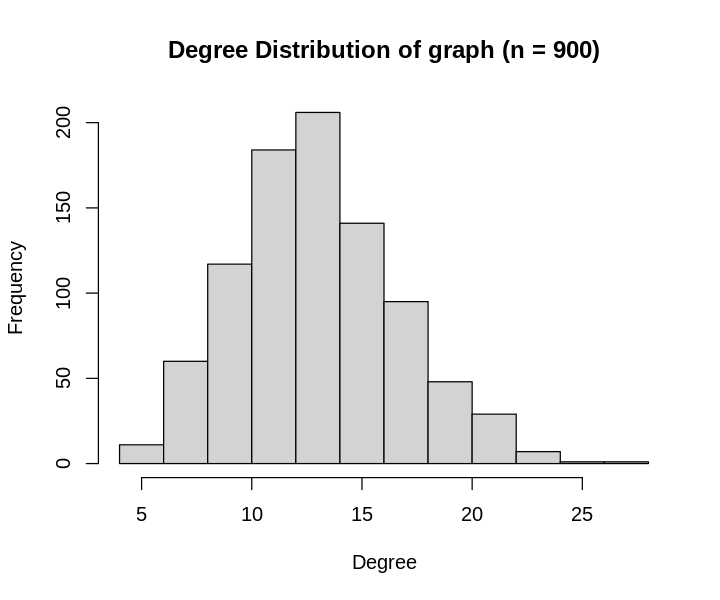

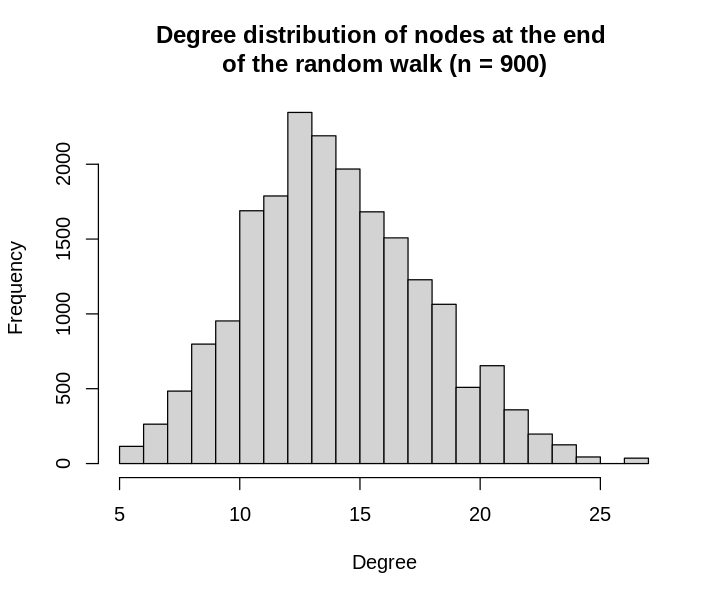

In [ ]:
# graph histogram
hist(degree(g), main="Degree Distribution of graph (n = 900)", xlab="Degree", ylab="Frequency")

# random walk histogram
hist(degree(g, all_nodes), main="Degree distribution of nodes at the end \nof the random walk (n = 900)", xlab="Degree", ylab="Frequency")

**Answer:** Both histograms of the degree distributions follow a normal distribution. The peaks are both around a degree of 13.

### d) undirected random networks with 9000 nodes

In [ ]:
set.seed(0)
g_9000 = sample_gnp(9000, 0.015)

is_connected(g_9000)

[1] TRUE

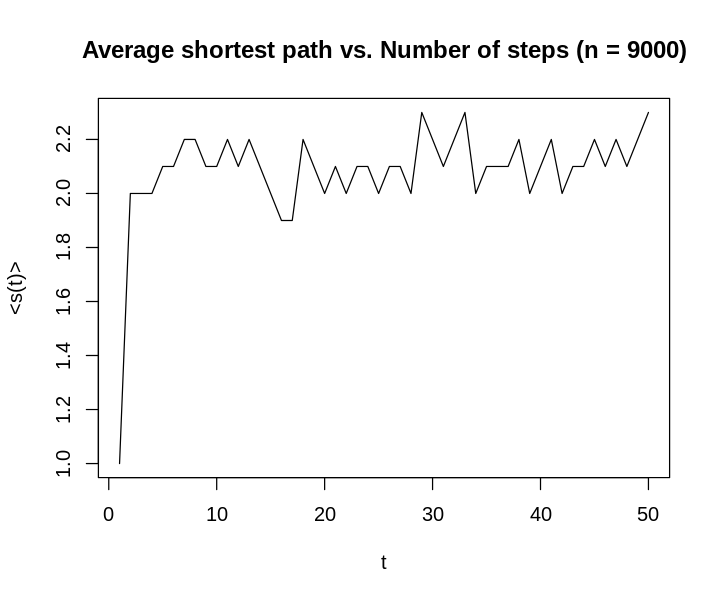

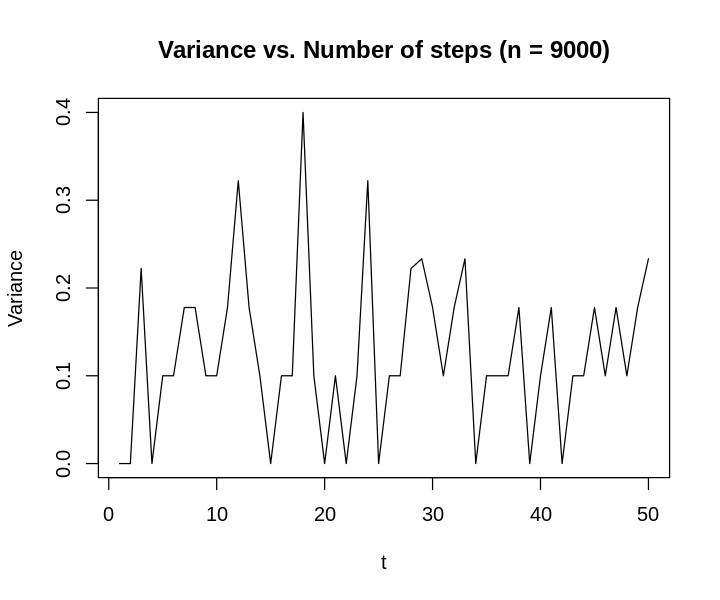

In [ ]:
# 1 hr
st <- c()
steps <- 50
num_trials <- 10
all_nodes <- c()
st_all <- list()
avg_all_st <- c()
var_ <- c()

for (n in 1: num_trials){
  start_node <- sample(V(g_9000), 1)
  v_last <- start_node
    for(i in 1:steps){
        v_last <- random_walk(g_9000, 1, v_last)

        edges_walked <- distances(g_9000, start_node, v_last)

        st[i] <- edges_walked
        all_nodes <- append(all_nodes, v_last)
    }

    st_all[[n]] <- st
}

for (i in 1:steps){
  st_i <- sapply(st_all, function(x) x[i])
  avg_all_st[i] <- mean(st_i)
  var_[i] <- var(st_i)
}

plot(1:length(avg_all_st), avg_all_st, xlab="t", ylab="<s(t)>", main="Average shortest path vs. Number of steps (n = 9000)", cex=0.5, type = 'l')
plot(1:length(var_), var_, xlab="t", ylab="Variance", main="Variance vs. Number of steps (n = 9000)", cex=0.5, type='l')

In [ ]:
# Diameter
paste("Diameter of ER Network (n = 900):", diameter(g))
paste("Diameter of ER Network (n = 9000):", diameter(g_9000))

[1] "Diameter of ER Network (n = 900): 5"

[1] "Diameter of ER Network (n = 9000): 3"

**Answer:**
Both the 900 node network and the 9000 node network converged quickly for the average shortest path plots, however the 9000 node network may have converged in fewer steps. The average shortest path in the 900 node network is consistently larger than the 9000 node network, with convergence around 2.8 compared to 2. The 9000 node network also shows less variance (max is 0.4, avg around 0.15) than in the 900 node network (max is 0.5, avg around 0.3). The variance in the 9000 node network is also smaller for each step than in the 900 node network.

Comparing these plots shows that the diameter of the network does play a role. The larger network, 9000 node network, with a shorter diameter of 3 converged to the average shortest path in fewer steps and has less variance than the smaller network of 900 nodes (diameter of 5).

## 2) Random walk on networks with Fat-tailed degree distribution

### a. Generate an undirected preferential attachment network with 900 nodes, where each
new node attaches to m = 1 old nodes.

In [ ]:
rw_pa_g <- sample_pa(n = 900, m = 1, directed=FALSE)

### b. Let a random walker start from a randomly selected node.
Measure and plot ⟨s(t)⟩ v.s. t and $σ^2(t)$ v.s. t.

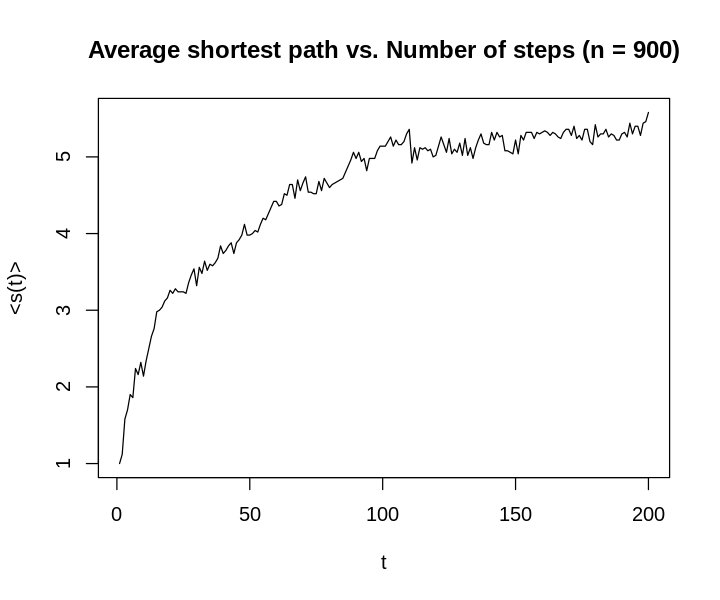

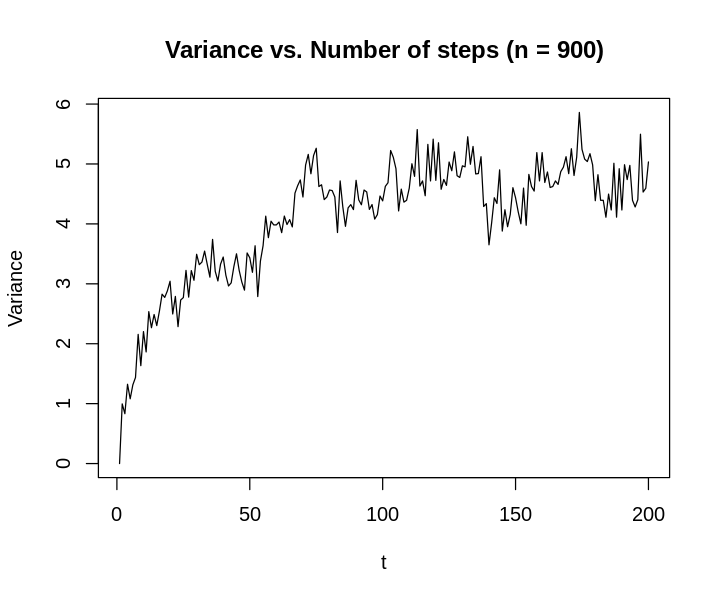

In [ ]:
# 17 min
st <- c()
steps <- 200
num_trials <- 100
all_nodes <- c()
st_all <- list()
avg_all_st <- c()
var_ <- c()

for (n in 1: num_trials){
  start_node <- sample(V(rw_pa_g), 1)
  v_last <- start_node
    for(i in 1:steps){
        v_last <- random_walk(rw_pa_g, 1, v_last)

        edges_walked <- distances(rw_pa_g, start_node, v_last)

        st[i] <- edges_walked
        all_nodes <- append(all_nodes, v_last)
    }

    st_all[[n]] <- st
}

for (i in 1:steps){
  st_i <- sapply(st_all, function(x) x[i])
  avg_all_st[i] <- mean(st_i)
  var_[i] <- var(st_i)
}

plot(1:length(avg_all_st), avg_all_st, xlab="t", ylab="<s(t)>", main="Average shortest path vs. Number of steps (n = 900)", cex=0.5, type = 'l')
plot(1:length(var_), var_, xlab="t", ylab="Variance", main="Variance vs. Number of steps (n = 900)", cex=0.5, type='l')

In [ ]:
paste("Diameter of PA Network (n = 900):", diameter(rw_pa_g))

[1] "Diameter of PA Network (n = 900): 19"

### c. Measure the degree distribution of the nodes reached at the end of the random walk
on this network

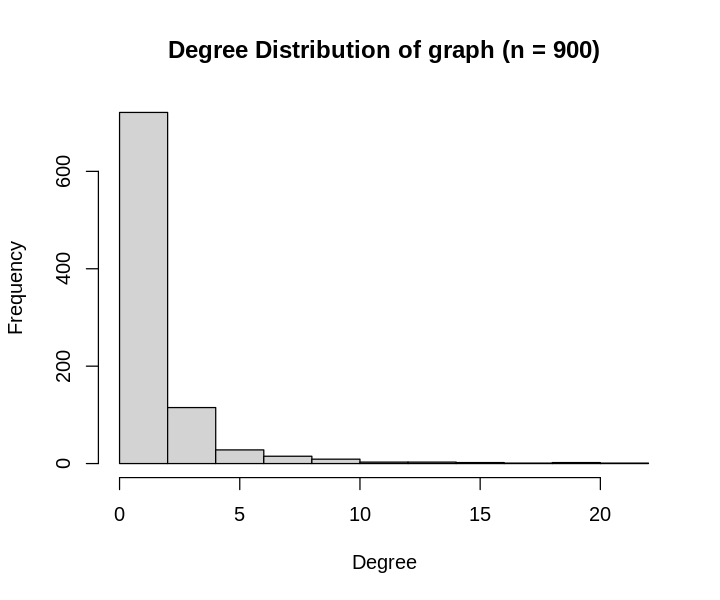

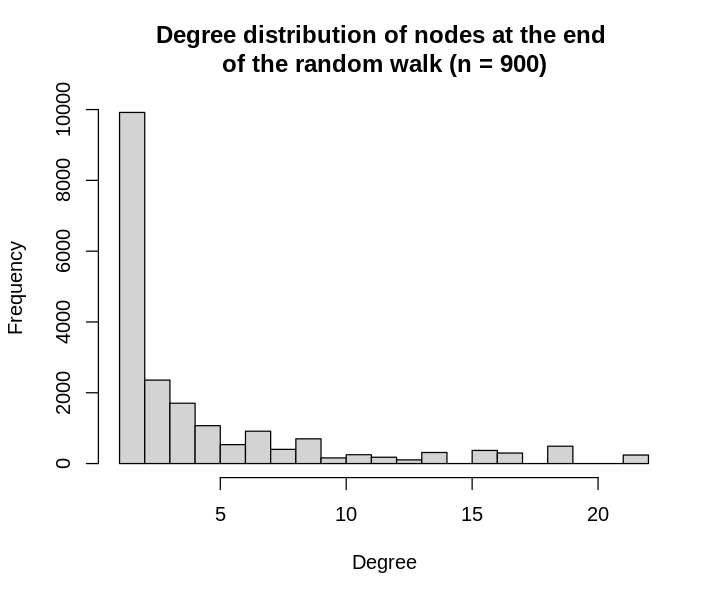

In [ ]:
# graph histogram
hist(degree(rw_pa_g), main="Degree Distribution of graph (n = 900)", xlab="Degree", ylab="Frequency")

# random walk histogram
hist(degree(rw_pa_g, all_nodes), main="Degree distribution of nodes at the end \nof the random walk (n = 900)", xlab="Degree", ylab="Frequency")

How does it compare with the degree distribution of the graph?

**Answer:**
Both distributions are strongly right skewed and show a fat-tailed distribution. In both distributions, the highest frequency of nodes are found with a 0 degree. There is a significant difference between the frequencies for the 0 degree and next lowest degree in both plots.

### d. Repeat 2(b) for preferential attachment networks with 90 and 9000 nodes, and m = 1.

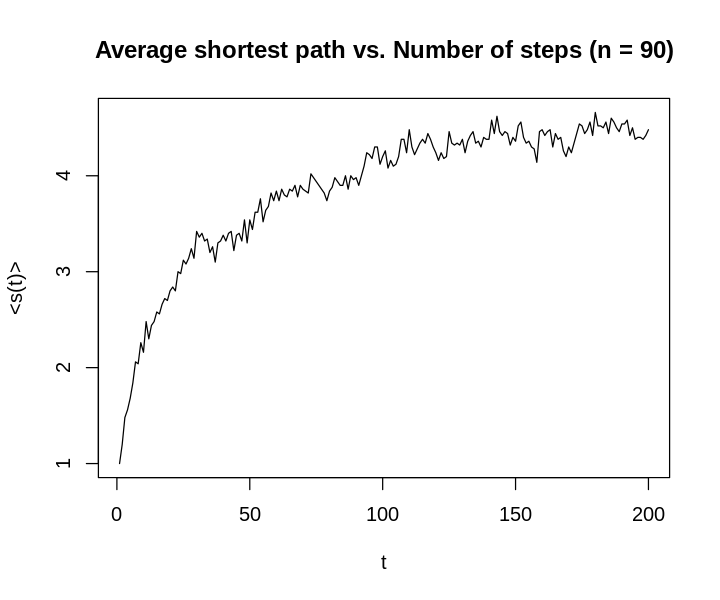

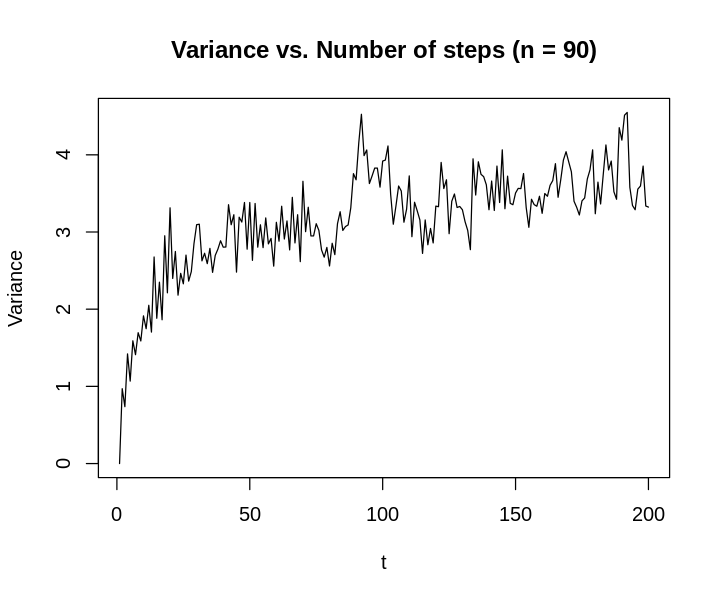

In [ ]:
#90

rw_pa_g_90 <- sample_pa(n = 90, m = 1, directed=FALSE)

st <- c()
steps <- 200
num_trials <- 100
all_nodes <- c()
st_all <- list()
avg_all_st <- c()
var_ <- c()

for (n in 1: num_trials){
  start_node <- sample(V(rw_pa_g_90), 1)
  v_last <- start_node
    for(i in 1:steps){
        v_last <- random_walk(rw_pa_g_90, 1, v_last)

        edges_walked <- distances(rw_pa_g_90, start_node, v_last)

        st[i] <- edges_walked
        all_nodes <- append(all_nodes, v_last)
    }

    st_all[[n]] <- st
}

for (i in 1:steps){
  st_i <- sapply(st_all, function(x) x[i])
  avg_all_st[i] <- mean(st_i)
  var_[i] <- var(st_i)
}

plot(1:length(avg_all_st), avg_all_st, xlab="t", ylab="<s(t)>", main="Average shortest path vs. Number of steps (n = 90)", cex=0.5, type = 'l')
plot(1:length(var_), var_, xlab="t", ylab="Variance", main="Variance vs. Number of steps (n = 90)", cex=0.5, type='l')

In [ ]:
paste("Diameter of PA Network (n = 90):", diameter(rw_pa_g_90))

[1] "Diameter of PA Network (n = 90): 12"

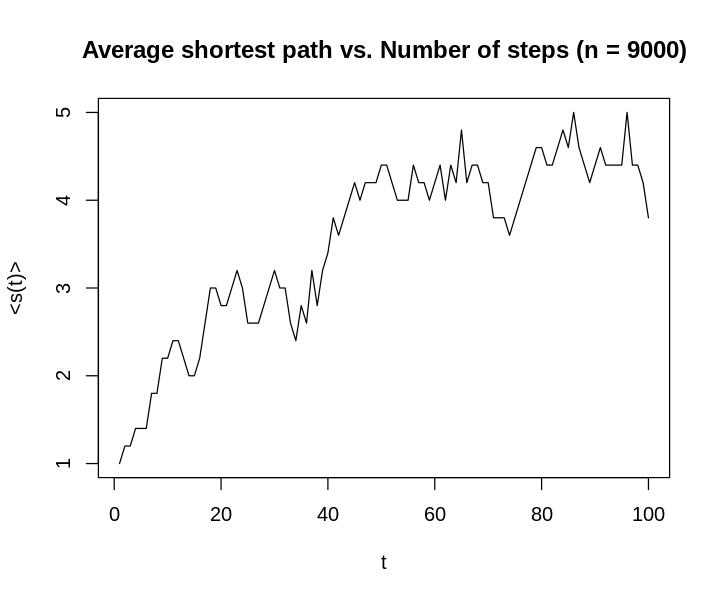

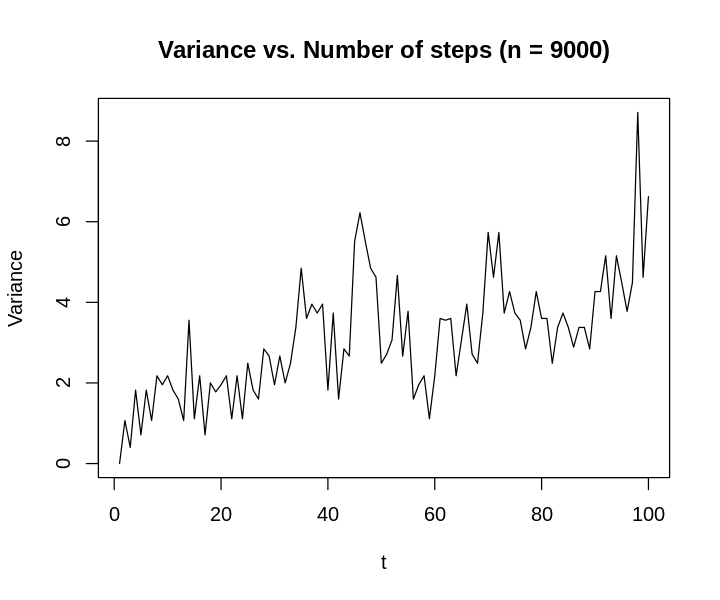

In [ ]:
#9000

rw_pa_g_9000 <- sample_pa(n = 9000, m = 1, directed=FALSE)

st <- c()
steps <- 100
num_trials <- 10
all_nodes <- c()
st_all <- list()
avg_all_st <- c()
var_ <- c()

for (n in 1: num_trials){
  start_node <- sample(V(rw_pa_g_9000), 1)
  v_last <- start_node
    for(i in 1:steps){
        v_last <- random_walk(rw_pa_g_9000, 1, v_last)

        edges_walked <- distances(rw_pa_g_9000, start_node, v_last)

        st[i] <- edges_walked
        all_nodes <- append(all_nodes, v_last)
    }

    st_all[[n]] <- st
}

for (i in 1:steps){
  st_i <- sapply(st_all, function(x) x[i])
  avg_all_st[i] <- mean(st_i)
  var_[i] <- var(st_i)
}

plot(1:length(avg_all_st), avg_all_st, xlab="t", ylab="<s(t)>", main="Average shortest path vs. Number of steps (n = 9000)", cex=0.5, type = 'l')
plot(1:length(var_), var_, xlab="t", ylab="Variance", main="Variance vs. Number of steps (n = 9000)", cex=0.5, type='l')

In [ ]:
paste("Diameter of PA Network (n = 9000):", diameter(rw_pa_g_9000))

[1] "Diameter of PA Network (n = 9000): 30"

**Answer:**

| n | max ⟨s(t)⟩ | $\sigma^2(t)$ | diameter |
|---|-----------|---------------|----------|
| 900 | < 6 | > 6 | 19 |
| 90 | ~ 4.5 | ~ 4 | 12 |
| 9000 | ~ 5| ~ 8 | 30 |

*Note, to reduce runtime we only ran the 9000 node network for 100 steps and 10 trials as opposed to 200 steps and 100 trials.

900 vs. 90 - The 900 node network has a larger average shortest path than the 90 node network. The variance of the 900 node network is larger than the 90 node network. Both networks did not converge after 200 steps.

900 vs. 9000 - The 900 and 9000 node networks seem to have similar average shortest path plots. The variance of the 9000 node network is larger than the 900 node network, but this may be due to fewer number of trials.

90 vs. 9000 - The 90 node network has a smaller average shortest path than the 9000 node network. The variance of the 90 node network is smaller than the 9000 node network.

## 3) Page Rank

The PageRank algorithm, as used by the Google search engine, exploits the linkage structure of the web to compute global “importance” scores that can be used to influence the ranking of search results. Here, we use random walk to simulate PageRank.

### a. Create a directed random network with 900 nodes, using the preferential attachment model.

Note that in a directed preferential attachment network, the out-degree of every node is m, while the in-degrees follow a power law distribution.
One problem of performing random walk in such a network is that, the very first node will have no outbounding edges, and be a “black hole” which a random walker can never “escape” from. To address that, let’s generate another 900-node random network with preferential attachment model, and merge the two networks by adding the edges of the second graph to the first graph with a shuffling of the indices of the nodes

Create such a network using m = 4. Measure the probability that the walker visits
 each node. Is this probability related to the degree of the nodes?

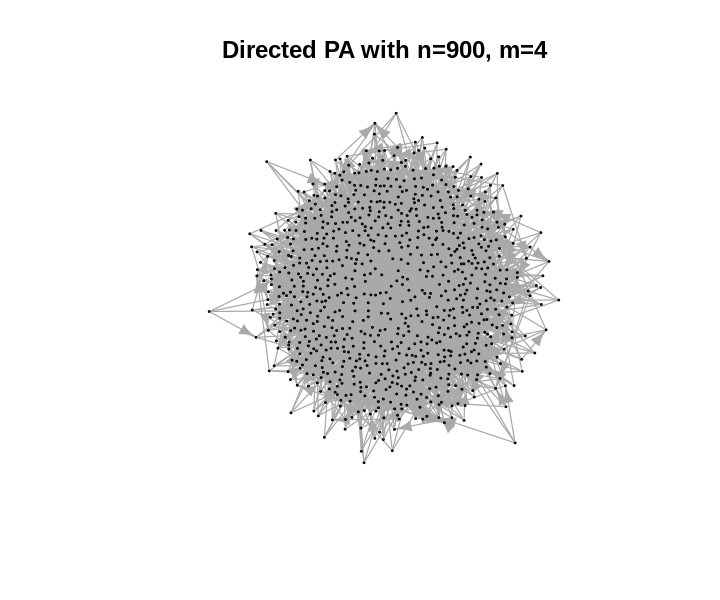

In [ ]:
#Network 1
set.seed(1)
pr_pa_g <- sample_pa(n=900, m=4, directed = TRUE)
plot(pr_pa_g, vertex.size=1, vertex.label=NA, main="Directed PA with n=900, m=4")

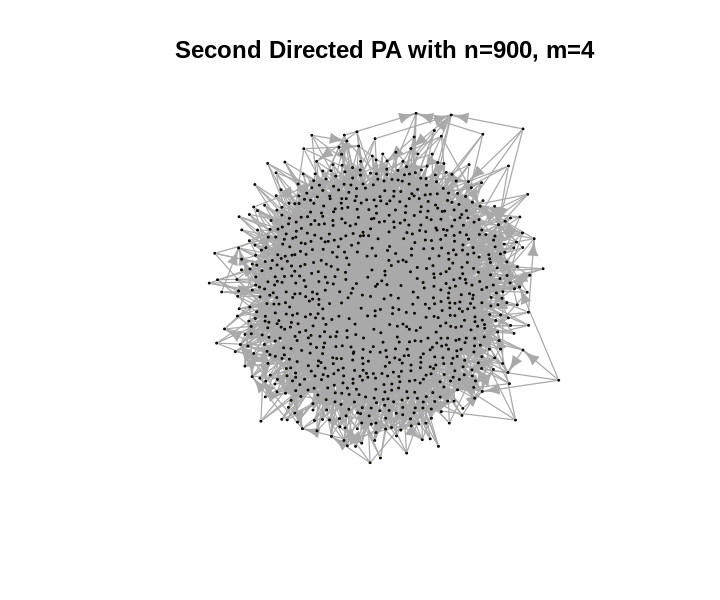

In [ ]:
#Network 2
pr_pa_g_2 <- sample_pa(n=900, m=4, directed = TRUE)
plot(pr_pa_g_2, vertex.size=1, vertex.label=NA, main="Second Directed PA with n=900, m=4")

permute_g <- permute(pr_pa_g_2, sample(vcount(pr_pa_g_2)))

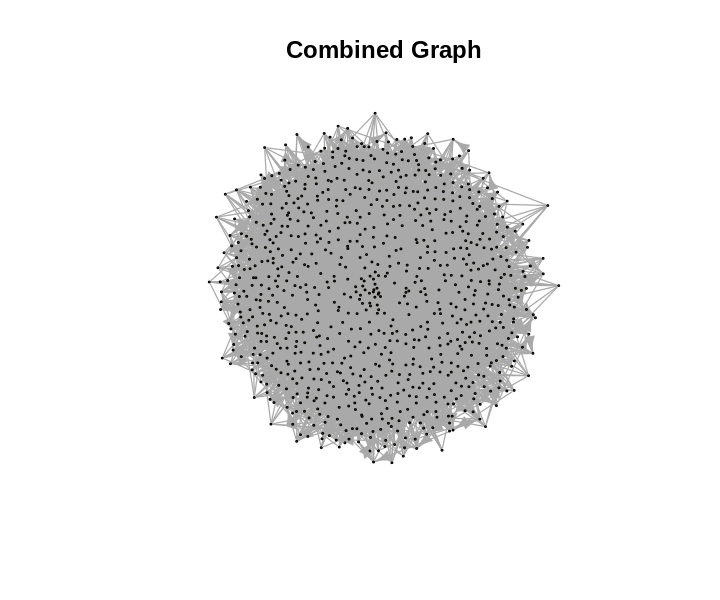

In [ ]:
combine_g <- add_edges(pr_pa_g, t(as_edgelist(permute_g)))
plot(combine_g, cex=0.5, vertex.size=1, vertex.label=NA, main="Combined Graph")

In [ ]:
# probability of visiting every node
num_trials <- 10
max_step <- 900
visits_node <- numeric(900)
start_node <- sample(V(combine_g), 1)

for (i in 1:max_step){
    current_node <- random_walk(combine_g, i, start_node)
    visits_node[current_node] <- visits_node[current_node] + 1
}

visits_node <- visits_node / max_step
degrees <- degree(combine_g, mode = "in")

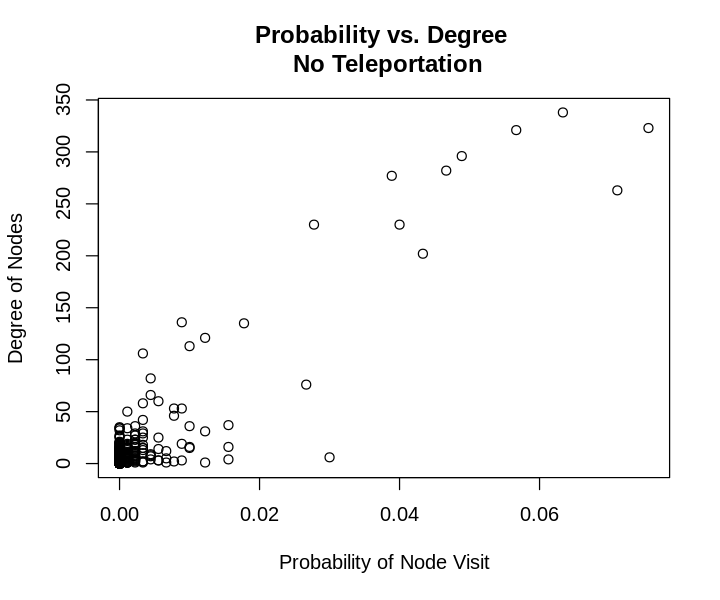

In [ ]:
# graph probability vs degree of node
plot(visits_node, degrees, xlab="Probability of Node Visit", ylab="Degree of Nodes", main="Probability vs. Degree \n No Teleportation")

**Answer:** The probability appears to be proportional to the degree of nodes. The majority of the nodes that have a low probability of being visited, have a small degree. The cluster of data points with a low degree and low probability are likely due to the fact that we are only taking 900 random steps.

### b. Now, we use a teleportation probability of α = 0.2 (teleport out of a node with prob=0.2 instead of going to its neighbor).

 By performing random walks on the network created in 3(a), measure the probability that the walker visits each node. How is this probability related to the degree of the node and α ?

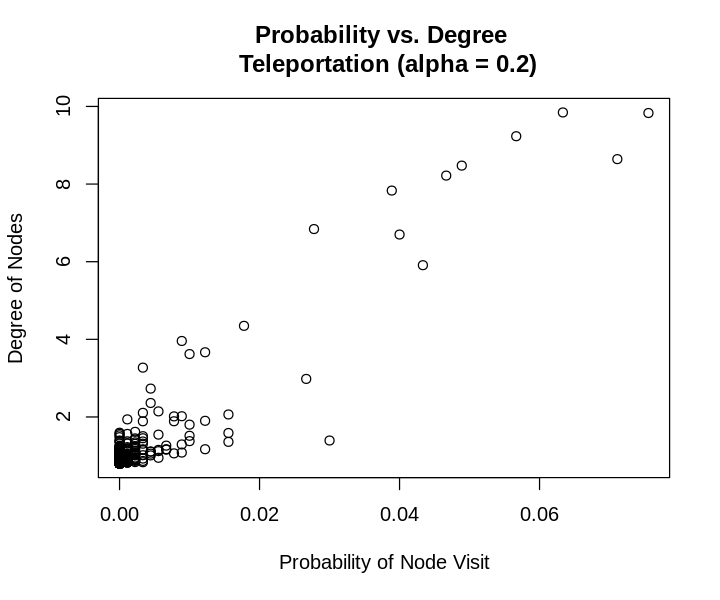

In [ ]:
pr_tel <- page_rank(combine_g, damping=0.2)
deg_tel <- degree(combine_g, mode = "in")
plot(visits_node, (pr_tel$vector * 900), xlab="Probability of Node Visit", ylab="Degree of Nodes", main="Probability vs. Degree \n Teleportation (alpha = 0.2)")

**Answer:** The probability appears to be proportional to the degree of nodes. The majority of the nodes that have a low probability of being visited, have a small degree. The cluster of data points with a low degree and low probability are likely due to the fact that we are only taking 900 random steps.

In comparison to the previous network without teleportation, the clusters around the low degree and low probability quadrant of the plots show slight differences. With teleportation, in general, the nodes with low degrees have slightly higher probabilities than without transportation. Adding an alpha value increases the probability.

## 4) Personalized PageRank

While the use of PageRank has proven very effective, the web’s rapid growth in size and diversity drives an increasing demand for greater flexibility in ranking. Ideally, each user should be able to define their own notion of importance for each individual query.

### a. Simulate personalized PageRank with α = 0.2

Compare results with 3a

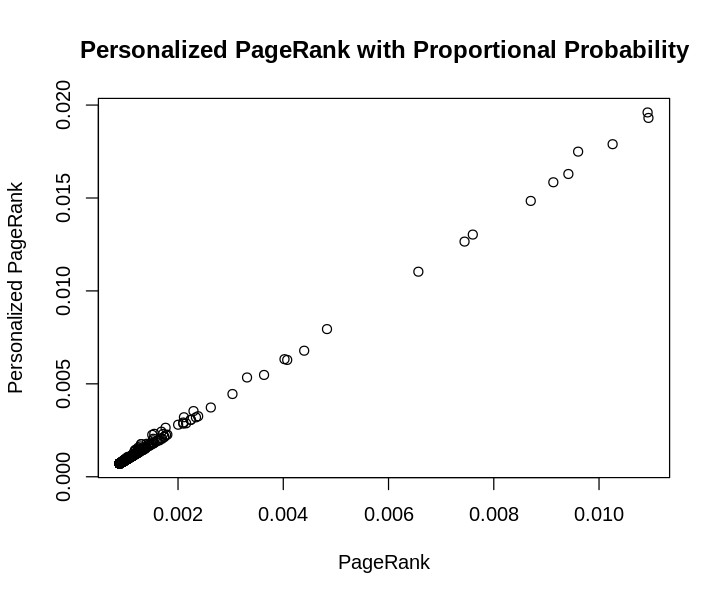

In [ ]:
pr <- page_rank(combine_g, damping=0.2)

perpr <- page_rank (combine_g, damping=0.2, personalized=pr$vector)

plot(pr$vector, perpr$vector, xlab="PageRank", ylab="Personalized PageRank", main="Personalized PageRank with Proportional Probability")

**Answer:** The personalized pagerank shows a strong positive linear relationship between the personalized probability and pagerank of the node. Compared to the regular pagerank plot, personalized pagerank shows a stronger linear relationship. Both have more datapoints towards the low probabilities side of the plot.

### b. Find two nodes in the network with median PageRanks. Repeat 4a if teleportations land only on those two nodes.

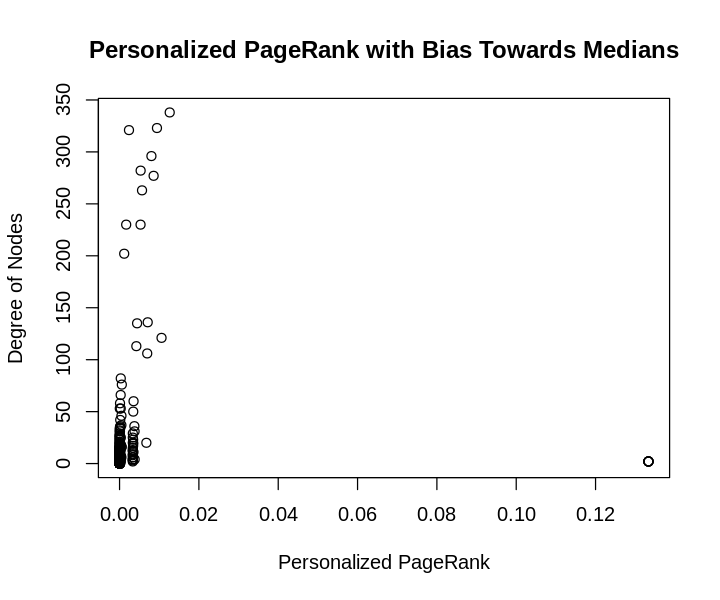

In [ ]:
pr_tel_per <- page_rank(combine_g, damping=0.2, personalized=pr_tel$vector)

median_pr <- median(pr_tel_per$vector)

ordered <- sort(pr_tel_per$vector)
len <- length(pr_tel_per$vector)
med1 <- ordered[(len+1)%/%2]
med2 <- ordered[(len+2)%/%2]

ind1 <- which(pr_tel_per$vector == med1)
ind2 <- which(pr_tel_per$vector == med2)

per_vector <- rep(0, vcount(combine_g))
per_vector[ind1] <- .5
per_vector[ind2] <- .5

pr_tel_per_1 <- page_rank(combine_g, damping=0.2, personalized=per_vector)
deg_tel_per_1 <- degree(combine_g, mode = "in")

plot(pr_tel_per_1$vector, deg_tel_per_1, xlab="Personalized PageRank", ylab="Degree of Nodes", main="Personalized PageRank with Bias Towards Medians")

How are the PageRank values affected?

**Answer:** For all nodes besides the medians, the probability of visiting those nodes in this network are around zero. The median probabilities changed from 0.5 to approximately 0.4. This is a very different trend than we have been observing in previous sections.

### c. Can you take into account the effect of this self-reinforcement and adjust the PageRank equation?

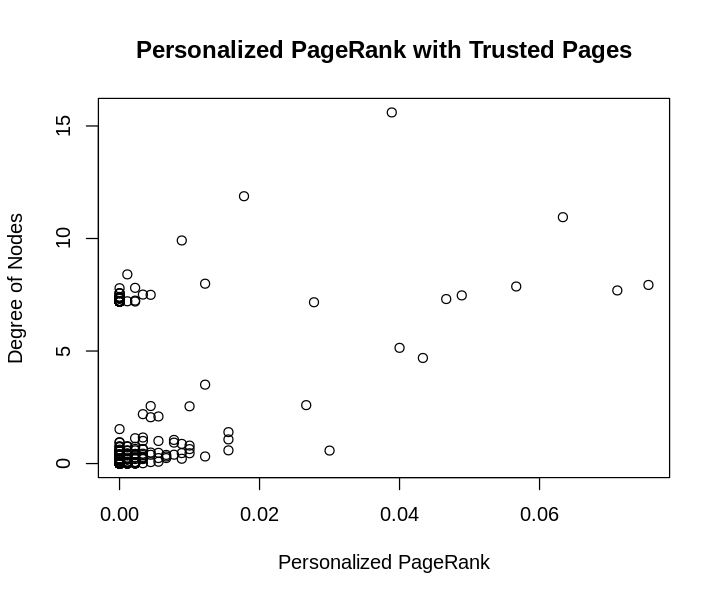

In [ ]:
# generate a set of trusted web pages
k = 100
trusted_nodes <- sample(V(combine_g), k)

# set up personalization with trusted pages
personalization <- rep(0, vcount(combine_g))
personalization[as_ids(trusted_nodes)] <- 1 / k

# get pagerank with personalization and plot
pr_tel_trust <- page_rank(combine_g, damping=0.2, personalized=personalization)
plot(visits_node, (pr_tel_trust$vector * 900), xlab="Personalized PageRank", ylab="Degree of Nodes", main="Personalized PageRank with Trusted Pages")

**Answer:**
The graph for our adjusted pagerank equation more closely resembles the graph for the regular page rank with teleportation. However, there are more nodes with a higher probability in our adjusted personalized graph than the original pagerank. This is likely due to our addition of trusted pages. These pages have a higher chance of the random walker teleporting to their nodes when stuck.